# Proyek Akhir: Membuat Model Sistem Rekomendasi
## Sistem Rekomendasi Film — *Content-Based Filtering* & *Collaborative Filtering*

- **Nama:** Andi Arif Abdillah
- **Kelas:** Machine Learning Terapan — Dicoding
- **Dataset:** [MovieLens *Small*](https://grouplens.org/datasets/movielens/latest/) (100.836 rating) — GroupLens Research, University of Minnesota

---

### Ringkasan Alur Notebook

| Tahap | Isi |
|---|---|
| 1 | Import *library* dan konfigurasi |
| 2 | *Data Loading* — pengunduhan dan pemuatan empat berkas dataset |
| 3 | *Data Understanding* — struktur, kondisi data, dan *exploratory data analysis* |
| 4 | *Data Preparation* — delapan tahap persiapan data yang berurutan |
| 5 | *Modeling* — tiga model rekomendasi dan satu *baseline* pembanding |
| 6 | *Evaluation* — metrik prediksi rating dan metrik peringkat (*ranking*) |
| 7 | Kesimpulan |

Seluruh keluaran notebook ini dapat direproduksi karena setiap sumber keacakan
dikunci dengan *random seed* yang tetap.

---
# 0. Project Overview dan Business Understanding

## Latar Belakang

Katalog layanan hiburan digital hari ini berisi puluhan ribu judul, jauh
melampaui kemampuan siapa pun untuk menelusurinya satu per satu. Ketika pilihan
terlalu banyak, pengguna justru sulit memutuskan — gejala yang dikenal sebagai
*choice overload*. Sistem rekomendasi hadir sebagai jawabannya: ia mempersempit
katalog raksasa menjadi belasan judul yang benar-benar layak dipertimbangkan
seorang pengguna.

Nilai ekonominya nyata. Netflix melaporkan bahwa lebih dari 80% jam tontonan di
platform mereka berasal dari rekomendasi, bukan dari pencarian mandiri, dan
menaksir nilai sistem rekomendasi mereka lebih dari satu miliar dolar per tahun
(Gomez-Uribe & Hunt, 2015). Bagi penyedia layanan, rekomendasi yang baik
menurunkan tingkat berhenti berlangganan sekaligus menghidupkan katalog bagian
ekor yang jarang tersentuh.

## Mengapa Proyek Ini Penting Diselesaikan

1. **Tanpa rekomendasi, katalog panjang menjadi beban, bukan aset.** Analisis
   data pada notebook ini menunjukkan hanya sekitar 7% film menyerap separuh
   seluruh rating, sementara 62% film menerima kurang dari lima rating. Ribuan
   judul praktis tidak pernah ditemukan siapa pun.
2. **Waktu pengguna terbatas.** Layar rekomendasi biasanya hanya memuat
   sekitar sepuluh judul. Setiap slot yang salah adalah kesempatan yang hilang.
3. **Pilihan pendekatan bukan hal sepele.** *Content-based filtering* dan
   *collaborative filtering* memiliki kekuatan dan kelemahan yang berbeda.
   Menentukan mana yang tepat memerlukan bukti kuantitatif, bukan asumsi.

## Problem Statements

1. Bagaimana merekomendasikan film yang relevan bagi seorang pengguna tanpa
   mengharuskannya menjelajahi katalog berisi ribuan judul?
2. Bagaimana sistem tetap dapat memberi rekomendasi untuk film yang jarang atau
   belum pernah dirating, yang jumlahnya mendominasi katalog?
3. Pendekatan mana yang lebih tepat untuk kasus ini, dan dengan bukti apa
   keunggulannya dapat dipertanggungjawabkan?

## Goals

1. Menghasilkan **top-10 rekomendasi film** yang dipersonalisasi bagi setiap
   pengguna.
2. Membangun sistem yang tetap mampu menjangkau film di ekor katalog, diukur
   melalui metrik cakupan katalog (*coverage*).
3. Membuktikan secara terukur bahwa model yang dipilih **mengungguli baseline
   populer** pada metrik Precision@10, Recall@10, dan NDCG@10.

## Solution Approach

**Pendekatan 1 — *Content-Based Filtering*.** Genre dan tag setiap film diubah
menjadi vektor TF-IDF, lalu kemiripan antarfilm dihitung dengan *cosine
similarity*. Rekomendasi disusun dari film yang kontennya paling mirip dengan
yang disukai pengguna.

**Pendekatan 2 — *Collaborative Filtering*.** Pola interaksi antarpengguna
dipelajari melalui faktorisasi matriks, dalam dua varian: *Matrix
Factorization* berbias yang dilatih dengan SGD pada rating eksplisit, dan
*Implicit ALS* yang dilatih pada sinyal biner "disukai".

Sebagai pembanding kelayakan, disertakan pula **baseline popularitas** yang
merekomendasikan film terpopuler kepada semua orang.

> Uraian lengkap latar belakang, riset terkait, dan pembahasan hasil disajikan
> pada berkas laporan `Laporan_Proyek_Sistem_Rekomendasi.md`.

---
# 1. Import Library

Proyek ini sengaja dibangun **tanpa pustaka sistem rekomendasi siap pakai**
(seperti `surprise` atau `implicit`). Kedua algoritma *collaborative filtering*
diimplementasikan langsung dengan NumPy agar setiap komponen matematis yang
dijelaskan pada laporan — fungsi objektif, aturan pembaruan, dan regularisasi —
benar-benar tercermin pada kode yang dijalankan.

In [1]:
import os
import re
import time
import zipfile
import urllib.request
from io import BytesIO

import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Saat berkas ini dijalankan sebagai skrip .py biasa (bukan di notebook),
# backend non-interaktif dipakai agar gambar tetap tersimpan ke folder images/
# tanpa membuka jendela yang menghentikan eksekusi.
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# Konfigurasi tampilan
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 10

# Kunci seluruh sumber keacakan
SEED = 42
np.random.seed(SEED)

# Direktori keluaran gambar untuk laporan
IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)


def simpan_gambar(nama):
    """Menyimpan figure yang aktif ke folder images/ agar dapat dirujuk laporan .md"""
    plt.savefig(os.path.join(IMG_DIR, nama))


print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('SciPy        :', scipy.__version__)
print('scikit-learn :', sklearn.__version__)

NumPy        : 2.2.6
pandas       : 2.3.3
SciPy        : 1.15.3
scikit-learn : 1.7.2


---
# 2. Data Loading

Dataset yang digunakan adalah **MovieLens *ml-latest-small*** yang dirilis oleh
[GroupLens Research](https://grouplens.org/datasets/movielens/latest/), sebuah
laboratorium riset di University of Minnesota. Berkas diunduh langsung dari
tautan resmi berikut:

> **Tautan unduh:** <https://files.grouplens.org/datasets/movielens/ml-latest-small.zip>

Sel di bawah memakai salinan lokal apabila tersedia; jika tidak, berkas akan
diunduh dan diekstrak secara otomatis. Dengan begitu notebook dapat dijalankan
ulang baik di Google Colab maupun di komputer lokal.

In [2]:
URL_DATASET = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
DIR_DATA = os.path.join('data', 'ml-latest-small')

if not os.path.exists(os.path.join(DIR_DATA, 'ratings.csv')):
    print('Mengunduh dataset dari GroupLens ...')
    with urllib.request.urlopen(URL_DATASET, timeout=120) as resp:
        konten = resp.read()
    zipfile.ZipFile(BytesIO(konten)).extractall('data')
    print('Selesai. Ukuran arsip: {:.1f} KB'.format(len(konten) / 1024))
else:
    print('Menggunakan salinan dataset yang sudah tersedia secara lokal.')

print('\nIsi direktori dataset:')
for berkas in sorted(os.listdir(DIR_DATA)):
    ukuran = os.path.getsize(os.path.join(DIR_DATA, berkas)) / 1024
    print(f'  - {berkas:<12} {ukuran:8.1f} KB')

Menggunakan salinan dataset yang sudah tersedia secara lokal.

Isi direktori dataset:
  - README.txt        8.1 KB
  - links.csv       193.3 KB
  - movies.csv      482.8 KB
  - ratings.csv    2425.5 KB
  - tags.csv        115.9 KB


### Memuat Keempat Berkas ke dalam DataFrame

Keempat berkas CSV dibaca sekaligus agar strukturnya dapat dibandingkan
berdampingan pada tahap pemahaman data.

In [3]:
ratings = pd.read_csv(os.path.join(DIR_DATA, 'ratings.csv'))
movies = pd.read_csv(os.path.join(DIR_DATA, 'movies.csv'))
tags = pd.read_csv(os.path.join(DIR_DATA, 'tags.csv'))
links = pd.read_csv(os.path.join(DIR_DATA, 'links.csv'))

print('Jumlah baris dan kolom tiap berkas')
for nama, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print(f'  {nama:<8}: {df.shape[0]:>6,} baris x {df.shape[1]} kolom')

Jumlah baris dan kolom tiap berkas
  ratings : 100,836 baris x 4 kolom
  movies  :  9,742 baris x 3 kolom
  tags    :  3,683 baris x 4 kolom
  links   :  9,742 baris x 3 kolom


---
# 3. Data Understanding

## 3.1 Struktur Berkas dan Uraian Variabel

Dataset terdiri atas empat berkas CSV yang saling terhubung melalui kunci
`movieId` dan `userId`.

In [4]:
for nama, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print('=' * 78)
    print(f'BERKAS: {nama}.csv  —  {df.shape[0]:,} baris, {df.shape[1]} kolom')
    print('=' * 78)
    df.info()
    print('\nCuplikan 5 baris pertama:')
    print(df.head().to_string(index=False))
    print()

BERKAS: ratings.csv  —  100,836 baris, 4 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Cuplikan 5 baris pertama:
 userId  movieId  rating  timestamp
      1        1     4.0  964982703
      1        3     4.0  964981247
      1        6     4.0  964982224
      1       47     5.0  964983815
      1       50     5.0  964982931

BERKAS: movies.csv  —  9,742 baris, 3 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   

### Uraian Seluruh Variabel

**`ratings.csv` — 100.836 baris (data interaksi utama)**

| Variabel | Tipe | Keterangan |
|---|---|---|
| `userId` | int64 | Identitas anonim pengguna. Setiap pengguna dijamin memiliki minimal 20 rating. |
| `movieId` | int64 | Identitas film; menjadi kunci penghubung ke `movies.csv`, `tags.csv`, dan `links.csv`. |
| `rating` | float64 | Penilaian eksplisit pengguna pada skala 0,5–5,0 dengan kelipatan 0,5 (10 tingkat). |
| `timestamp` | int64 | Waktu pemberian rating dalam detik sejak 1 Januari 1970 (UTC). Dipakai untuk pemisahan data secara temporal. |

**`movies.csv` — 9.742 baris (metadata konten)**

| Variabel | Tipe | Keterangan |
|---|---|---|
| `movieId` | int64 | Identitas film. |
| `title` | object | Judul film beserta tahun rilis dalam tanda kurung, contoh `Toy Story (1995)`. |
| `genres` | object | Daftar genre yang dipisahkan tanda pipa, contoh `Adventure\|Animation\|Children`. Terdapat 19 kategori genre serta nilai khusus `(no genres listed)`. |

**`tags.csv` — 3.683 baris (metadata konten yang berasal dari pengguna)**

| Variabel | Tipe | Keterangan |
|---|---|---|
| `userId` | int64 | Pengguna yang memberi tag. |
| `movieId` | int64 | Film yang diberi tag. |
| `tag` | object | Kata atau frasa bebas buatan pengguna, contoh `pixar`, `dark comedy`, `based on a book`. |
| `timestamp` | int64 | Waktu pemberian tag. |

**`links.csv` — 9.742 baris (pranala ke basis data film eksternal)**

| Variabel | Tipe | Keterangan |
|---|---|---|
| `movieId` | int64 | Identitas film pada MovieLens. |
| `imdbId` | int64 | Identitas film yang bersesuaian pada IMDb. |
| `tmdbId` | float64 | Identitas film yang bersesuaian pada TMDB; terdapat 8 nilai kosong. |

Berkas `links.csv` hanya berguna untuk pengayaan data dari sumber eksternal
(misalnya poster atau sinopsis) sehingga **tidak dipakai** pada proyek ini.

## 3.2 Kondisi Data

Pemeriksaan kondisi data mencakup empat hal: nilai kosong (*missing value*),
duplikasi baris, duplikasi pasangan kunci `(userId, movieId)`, dan konsistensi
rentang nilai.

In [5]:
print('--- Nilai kosong (missing value) per berkas ---')
for nama, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    kosong = df.isna().sum()
    kosong = kosong[kosong > 0]
    if len(kosong) == 0:
        print(f'  {nama:<8}: tidak ada nilai kosong')
    else:
        print(f'  {nama:<8}: {kosong.to_dict()}')

print('\n--- Duplikasi baris utuh ---')
for nama, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print(f'  {nama:<8}: {df.duplicated().sum()} baris duplikat')

print('\n--- Duplikasi pasangan kunci ---')
print('  ratings (userId, movieId):', ratings.duplicated(subset=['userId', 'movieId']).sum())
print('  movies  (movieId)        :', movies.duplicated(subset=['movieId']).sum())
print('  movies  (title)          :', movies.duplicated(subset=['title']).sum())

print('\n--- Konsistensi rentang nilai ---')
print('  Rentang rating           :', ratings.rating.min(), '-', ratings.rating.max())
print('  Nilai rating unik        :', sorted(ratings.rating.unique()))
print('  Rentang waktu pengamatan :',
      pd.to_datetime(ratings.timestamp, unit='s').min().date(), 's/d',
      pd.to_datetime(ratings.timestamp, unit='s').max().date())
print('  movieId pada ratings yang tidak ada di movies:',
      int((~ratings.movieId.isin(movies.movieId)).sum()))

--- Nilai kosong (missing value) per berkas ---
  ratings : tidak ada nilai kosong
  movies  : tidak ada nilai kosong
  tags    : tidak ada nilai kosong
  links   : {'tmdbId': 8}

--- Duplikasi baris utuh ---
  ratings : 0 baris duplikat
  movies  : 0 baris duplikat
  tags    : 0 baris duplikat
  links   : 0 baris duplikat

--- Duplikasi pasangan kunci ---
  ratings (userId, movieId): 0
  movies  (movieId)        : 0
  movies  (title)          : 5

--- Konsistensi rentang nilai ---
  Rentang rating           : 0.5 - 5.0
  Nilai rating unik        : [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


  Rentang waktu pengamatan : 1996-03-29 s/d 2018-09-24
  movieId pada ratings yang tidak ada di movies: 0


### Statistik Deskriptif dan Skala Masalah

Sel berikut merangkum sebaran nilai rating sekaligus menghitung tingkat
kerenggangan (*sparsity*) matriks interaksi — angka yang menentukan seberapa
sulit persoalan yang dihadapi kedua pendekatan rekomendasi.

In [6]:
print('--- Statistik deskriptif kolom rating ---')
print(ratings.rating.describe().round(3).to_string())

n_user = ratings.userId.nunique()
n_movie_rated = ratings.movieId.nunique()
n_movie_total = movies.movieId.nunique()
sparsity = 1 - len(ratings) / (n_user * n_movie_rated)

print('\n--- Ringkasan skala masalah ---')
print(f'  Jumlah pengguna unik             : {n_user:,}')
print(f'  Jumlah film pada katalog         : {n_movie_total:,}')
print(f'  Jumlah film yang pernah dirating : {n_movie_rated:,}')
print(f'  Jumlah film tanpa satu pun rating: {n_movie_total - n_movie_rated:,}')
print(f'  Jumlah rating                    : {len(ratings):,}')
print(f'  Kepadatan matriks interaksi      : {(1 - sparsity) * 100:.2f}%')
print(f'  Tingkat kerenggangan (sparsity)  : {sparsity * 100:.2f}%')

--- Statistik deskriptif kolom rating ---
count    100836.000
mean          3.502
std           1.043
min           0.500
25%           3.000
50%           3.500
75%           4.000
max           5.000

--- Ringkasan skala masalah ---
  Jumlah pengguna unik             : 610
  Jumlah film pada katalog         : 9,742
  Jumlah film yang pernah dirating : 9,724
  Jumlah film tanpa satu pun rating: 18
  Jumlah rating                    : 100,836
  Kepadatan matriks interaksi      : 1.70%
  Tingkat kerenggangan (sparsity)  : 98.30%


**Kondisi data secara ringkas:**

1. **Tidak ada nilai kosong** pada `ratings`, `movies`, maupun `tags`. Delapan
   nilai kosong hanya terdapat pada kolom `tmdbId` di `links.csv`, berkas yang
   tidak dipakai pada proyek ini.
2. **Tidak ada baris duplikat** dan tidak ada pasangan `(userId, movieId)`
   ganda, sehingga setiap pengguna hanya memberi satu rating untuk satu film.
3. **Seluruh nilai rating berada pada rentang yang sah** (0,5–5,0 dengan
   kelipatan 0,5), dan setiap `movieId` pada `ratings` selalu ditemukan pada
   `movies` sehingga tidak ada relasi yang menggantung.
4. Terdapat **18 film yang belum pernah dirating sama sekali** — kasus
   *cold-start item* yang nyata pada data.
5. Matriks interaksi sangat renggang: hanya sekitar **1,70%** sel yang terisi.
   Kerenggangan inilah tantangan utama sistem rekomendasi.

## 3.3 Exploratory Data Analysis (EDA)

Bagian ini menggali karakteristik data melalui visualisasi. Setiap gambar
disertai *insight* yang kemudian menjadi dasar keputusan pada tahap
*Data Preparation* dan *Modeling*.

### 3.3.1 Distribusi Nilai Rating

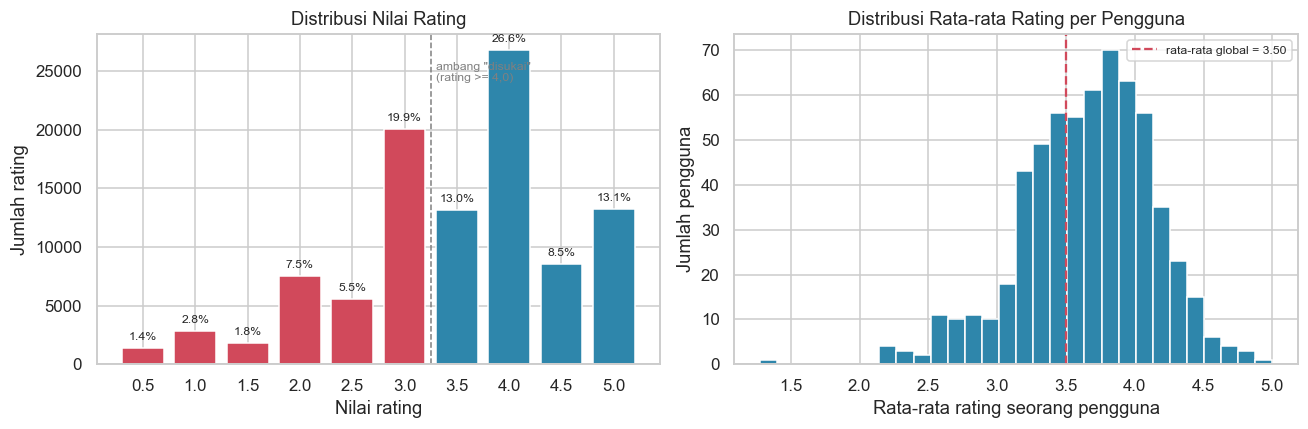

Proporsi rating >= 4,0 (kategori "disukai"): 48.2%
Rata-rata rating global : 3.502
Median rating global    : 3.5
Sebaran rata-rata rating antar pengguna: min=1.27, maks=5.00, std=0.48


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

urut = sorted(ratings.rating.unique())
frek = ratings.rating.value_counts().reindex(urut)
warna = ['#d1495b' if r < 3.5 else '#2e86ab' for r in urut]
ax[0].bar([str(r) for r in urut], frek.values, color=warna)
for i, v in enumerate(frek.values):
    ax[0].text(i, v + 700, f'{v/len(ratings)*100:.1f}%', ha='center', fontsize=8)
ax[0].set_title('Distribusi Nilai Rating')
ax[0].set_xlabel('Nilai rating')
ax[0].set_ylabel('Jumlah rating')
ax[0].axvline(x=5.5, color='gray', ls='--', lw=1)
ax[0].text(5.6, frek.max() * 0.9, 'ambang "disukai"\n(rating >= 4,0)', fontsize=8, color='gray')

rata_user = ratings.groupby('userId').rating.mean()
ax[1].hist(rata_user, bins=30, color='#2e86ab', edgecolor='white')
ax[1].axvline(ratings.rating.mean(), color='#d1495b', ls='--',
              label=f'rata-rata global = {ratings.rating.mean():.2f}')
ax[1].set_title('Distribusi Rata-rata Rating per Pengguna')
ax[1].set_xlabel('Rata-rata rating seorang pengguna')
ax[1].set_ylabel('Jumlah pengguna')
ax[1].legend(fontsize=8)

plt.tight_layout()
simpan_gambar('fig_01_distribusi_rating.png')
plt.show()

print('Proporsi rating >= 4,0 (kategori "disukai"):',
      f'{(ratings.rating >= 4).mean() * 100:.1f}%')
print('Rata-rata rating global :', round(ratings.rating.mean(), 3))
print('Median rating global    :', ratings.rating.median())
print('Sebaran rata-rata rating antar pengguna: min={:.2f}, maks={:.2f}, std={:.2f}'.format(
    rata_user.min(), rata_user.max(), rata_user.std()))

**Insight 1 — Rating condong ke nilai tinggi dan setiap pengguna punya "gaya menilai" sendiri.**

Nilai 4,0 adalah rating yang paling sering diberikan dan sekitar 48% rating
bernilai ≥ 4,0. Distribusi yang miring ke kanan ini wajar pada data rekomendasi
karena pengguna cenderung hanya menonton film yang memang mereka minati.
Konsekuensinya, **rating 3,0 bukan berarti "netral"** melainkan relatif rendah.

Panel kanan memperlihatkan hal yang lebih penting: rata-rata rating antarpengguna
tersebar luas dari sekitar 1,3 sampai 5,0. Ada pengguna yang murah hati dan ada
yang pelit memberi nilai. Perbedaan sistematis ini yang nantinya ditangani
secara eksplisit oleh **suku bias pengguna** ($b_u$) pada model *Matrix
Factorization*, sehingga model tidak salah menafsirkan rating 3,5 dari pengguna
pelit sebagai sinyal negatif.

### 3.3.2 Pola Ekor Panjang (*Long Tail*)

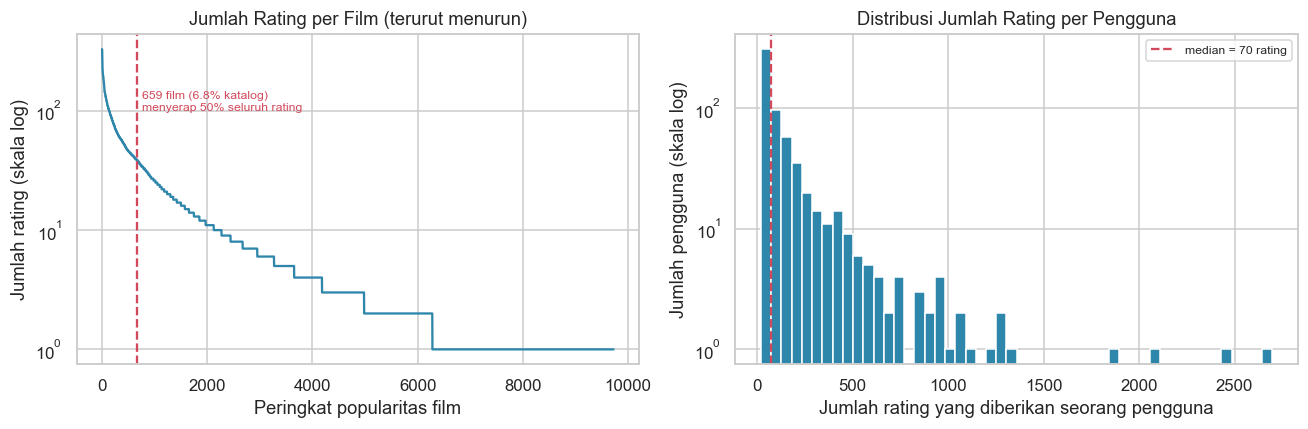

--- Statistik jumlah rating per FILM ---
count    9724.00
mean       10.37
std        22.40
min         1.00
25%         1.00
50%         3.00
75%         9.00
max       329.00

  Film dengan < 5 rating : 6,074 (62.5% dari film yang pernah dirating)
  Film dengan 1 rating   : 3,446

--- Statistik jumlah rating per PENGGUNA ---
count     610.00
mean      165.30
std       269.48
min        20.00
25%        35.00
50%        70.50
75%       168.00
max      2698.00


In [8]:
rating_per_film = ratings.groupby('movieId').size().sort_values(ascending=False)
rating_per_user = ratings.groupby('userId').size().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(np.arange(1, len(rating_per_film) + 1), rating_per_film.values, color='#2e86ab')
ax[0].set_yscale('log')
ax[0].set_title('Jumlah Rating per Film (terurut menurun)')
ax[0].set_xlabel('Peringkat popularitas film')
ax[0].set_ylabel('Jumlah rating (skala log)')
n_top = int((rating_per_film.cumsum() <= len(ratings) * 0.5).sum()) + 1
ax[0].axvline(n_top, color='#d1495b', ls='--')
ax[0].text(n_top * 1.15, 100,
           f'{n_top} film ({n_top/len(rating_per_film)*100:.1f}% katalog)\nmenyerap 50% seluruh rating',
           fontsize=8, color='#d1495b')

ax[1].hist(rating_per_user.values, bins=50, color='#2e86ab', edgecolor='white')
ax[1].set_yscale('log')
ax[1].set_title('Distribusi Jumlah Rating per Pengguna')
ax[1].set_xlabel('Jumlah rating yang diberikan seorang pengguna')
ax[1].set_ylabel('Jumlah pengguna (skala log)')
ax[1].axvline(rating_per_user.median(), color='#d1495b', ls='--',
              label=f'median = {int(rating_per_user.median())} rating')
ax[1].legend(fontsize=8)

plt.tight_layout()
simpan_gambar('fig_02_long_tail.png')
plt.show()

print('--- Statistik jumlah rating per FILM ---')
print(rating_per_film.describe().round(2).to_string())
print(f'\n  Film dengan < 5 rating : {(rating_per_film < 5).sum():,} '
      f'({(rating_per_film < 5).mean()*100:.1f}% dari film yang pernah dirating)')
print(f'  Film dengan 1 rating   : {(rating_per_film == 1).sum():,}')

print('\n--- Statistik jumlah rating per PENGGUNA ---')
print(rating_per_user.describe().round(2).to_string())

**Insight 2 — Data sangat timpang, baik di sisi film maupun di sisi pengguna.**

Hanya sekitar 7% film (659 judul) yang menyerap separuh dari seluruh rating, sementara lebih dari
separuh film memiliki kurang dari 5 rating dan 3.446 film bahkan hanya dirating
satu kali. Pola *long tail* ini punya dua akibat langsung:

1. *Collaborative filtering* **tidak punya sinyal yang memadai** untuk film di
   ekor distribusi. Karena itu, pada tahap evaluasi peringkat digunakan
   *candidate pool* berisi film dengan minimal 5 rating (lihat tahap
   persiapan data ke-8).
2. Model yang sekadar merekomendasikan film terpopuler bisa terlihat "cukup
   baik" secara angka. Karena itu **baseline popularitas wajib disertakan**
   sebagai pembanding — tanpa itu, kita tidak dapat membuktikan model benar-benar
   mempelajari selera dan bukan sekadar mengikuti arus.

Di sisi pengguna, distribusi juga sangat miring: median hanya sekitar 70 rating,
sedangkan pengguna paling aktif memberi 2.698 rating. Model perlu bekerja baik
untuk pengguna dengan riwayat pendek maupun panjang.

### 3.3.3 Genre: Sebaran Katalog dan Kualitas Persepsi

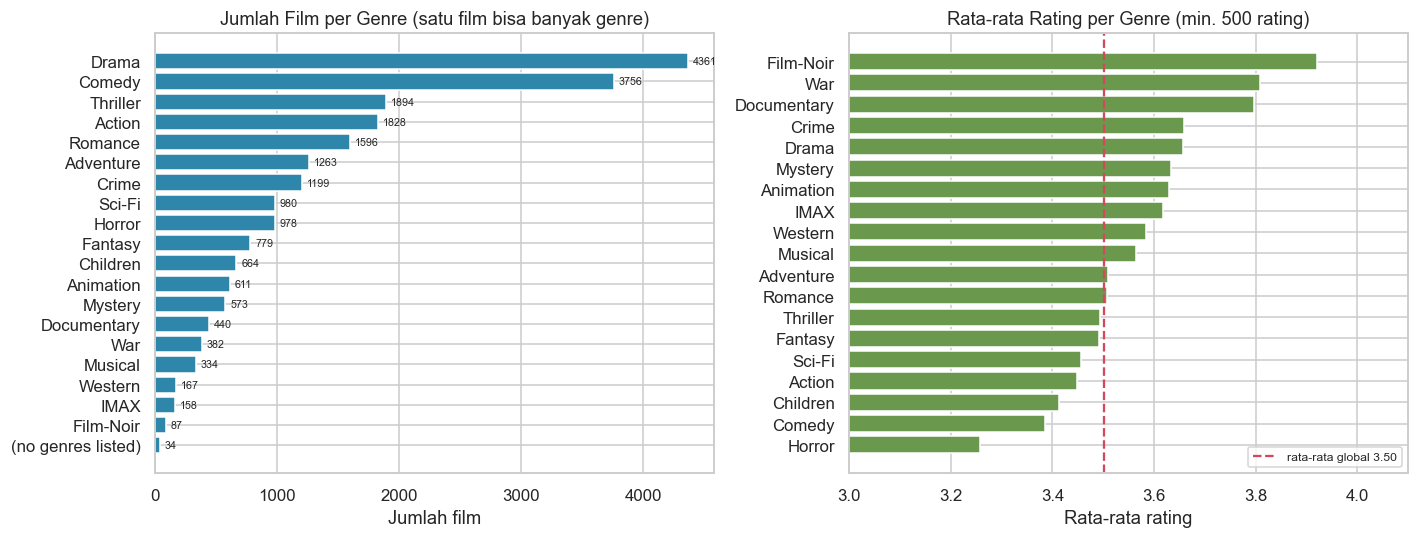

Jumlah kategori genre unik : 20
Film tanpa genre           : 34
Rata-rata genre per film   : 2.27

Lima genre terbanyak:
genre
Drama       4361
Comedy      3756
Thriller    1894
Action      1828
Romance     1596

Tiga genre dengan rata-rata rating tertinggi:
             rata_rating  jumlah_rating
genre                                  
Documentary        3.798           1219
War                3.808           4859
Film-Noir          3.920            870


In [9]:
genre_exploded = (movies.assign(genre=movies.genres.str.split('|'))
                        .explode('genre'))
jumlah_genre = genre_exploded.genre.value_counts()

rating_genre = (ratings.merge(genre_exploded[['movieId', 'genre']], on='movieId')
                       .groupby('genre')
                       .agg(rata_rating=('rating', 'mean'), jumlah_rating=('rating', 'size')))
rating_genre = rating_genre[rating_genre.jumlah_rating >= 500].sort_values('rata_rating')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].barh(jumlah_genre.index[::-1], jumlah_genre.values[::-1], color='#2e86ab')
ax[0].set_title('Jumlah Film per Genre (satu film bisa banyak genre)')
ax[0].set_xlabel('Jumlah film')
for i, v in enumerate(jumlah_genre.values[::-1]):
    ax[0].text(v + 40, i, str(v), va='center', fontsize=7)

ax[1].barh(rating_genre.index, rating_genre.rata_rating, color='#6a994e')
ax[1].axvline(ratings.rating.mean(), color='#d1495b', ls='--',
              label=f'rata-rata global {ratings.rating.mean():.2f}')
ax[1].set_xlim(3.0, 4.1)
ax[1].set_title('Rata-rata Rating per Genre (min. 500 rating)')
ax[1].set_xlabel('Rata-rata rating')
ax[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
simpan_gambar('fig_03_genre.png')
plt.show()

print('Jumlah kategori genre unik :', movies.genres.str.split('|').explode().nunique())
print('Film tanpa genre           :', int((movies.genres == '(no genres listed)').sum()))
print('Rata-rata genre per film   :', round(movies.genres.str.split('|').apply(len).mean(), 2))
print('\nLima genre terbanyak:')
print(jumlah_genre.head().to_string())
print('\nTiga genre dengan rata-rata rating tertinggi:')
print(rating_genre.tail(3).round(3).to_string())

**Insight 3 — Genre adalah fitur yang informatif tetapi kasar.**

`Drama` dan `Comedy` mendominasi katalog dengan lebih dari 4.300 dan 3.700 film.
Rata-rata satu film memiliki 2,27 genre, sehingga genre dapat dijadikan
representasi konten yang bermakna. Perbedaan rata-rata rating antargenre juga
nyata: `Film-Noir`, `War`, dan `Documentary` konsisten dinilai lebih tinggi,
sedangkan `Horror` dan `Comedy` berada di bawah rata-rata global.

Namun perlu dicatat sejak awal: hanya ada 19 kategori genre untuk 9.742 film.
Artinya ribuan film berbagi kombinasi genre yang **persis sama** — misalnya
ratusan film sekaligus berlabel `Comedy|Drama|Romance`. Keterbatasan resolusi
inilah alasan proyek ini **memperkaya representasi konten dengan tag buatan
pengguna** (lihat tahap persiapan data ke-4), sekaligus alasan teoretis mengapa
*content-based filtering* diperkirakan kalah presisi dibanding *collaborative
filtering* — dugaan yang nanti diuji secara kuantitatif pada bagian Evaluasi.

### 3.3.4 Film Terpopuler dan Hubungan Popularitas–Kualitas

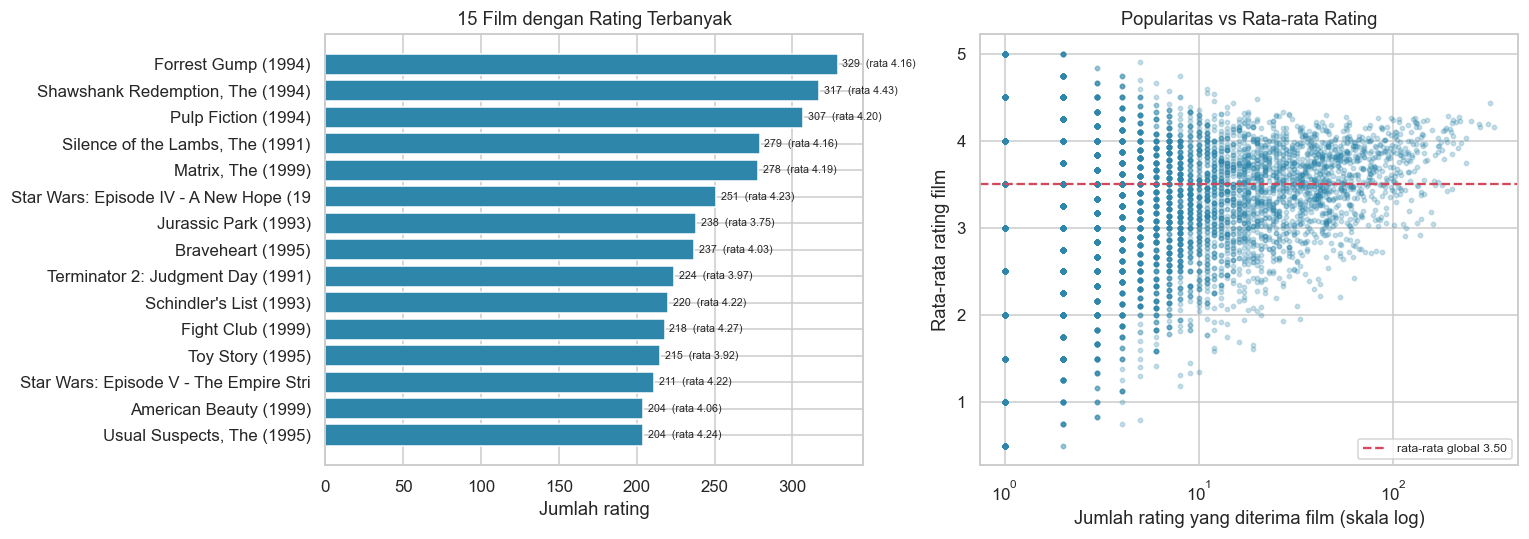

Korelasi Pearson antara log(jumlah rating) dan rata-rata rating: 0.112

Contoh film dengan rata-rata 5,0 tetapi hanya 1 rating:
                                            title  jumlah  rata
                 Awfully Big Adventure, An (1995)       1   5.0
                           Live Nude Girls (1995)       1   5.0
In the Realm of the Senses (Ai no corrida) (1976)       1   5.0
                      What Happened Was... (1994)       1   5.0
        Thin Line Between Love and Hate, A (1996)       1   5.0


In [10]:
info_film = (ratings.groupby('movieId')
                    .agg(jumlah=('rating', 'size'), rata=('rating', 'mean'))
                    .merge(movies[['movieId', 'title']], on='movieId'))
teratas = info_film.sort_values('jumlah', ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].barh(teratas.title.str.slice(0, 38)[::-1], teratas.jumlah[::-1], color='#2e86ab')
ax[0].set_title('15 Film dengan Rating Terbanyak')
ax[0].set_xlabel('Jumlah rating')
for i, (n, r) in enumerate(zip(teratas.jumlah[::-1], teratas.rata[::-1])):
    ax[0].text(n + 3, i, f'{n}  (rata {r:.2f})', va='center', fontsize=7)

ax[1].scatter(info_film.jumlah, info_film.rata, s=8, alpha=0.25, color='#2e86ab')
ax[1].set_xscale('log')
ax[1].set_xlabel('Jumlah rating yang diterima film (skala log)')
ax[1].set_ylabel('Rata-rata rating film')
ax[1].set_title('Popularitas vs Rata-rata Rating')
ax[1].axhline(ratings.rating.mean(), color='#d1495b', ls='--',
              label=f'rata-rata global {ratings.rating.mean():.2f}')
ax[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
simpan_gambar('fig_04_popularitas.png')
plt.show()

korelasi = np.corrcoef(np.log1p(info_film.jumlah), info_film.rata)[0, 1]
print(f'Korelasi Pearson antara log(jumlah rating) dan rata-rata rating: {korelasi:.3f}')
print('\nContoh film dengan rata-rata 5,0 tetapi hanya 1 rating:')
print(info_film[(info_film.rata == 5.0) & (info_film.jumlah == 1)]
      .head(5)[['title', 'jumlah', 'rata']].to_string(index=False))

**Insight 4 — Rata-rata rating mentah tidak layak dijadikan dasar peringkat.**

Diagram sebar memperlihatkan bentuk corong yang khas: film dengan sedikit rating
menyebar dari 0,5 sampai 5,0, sementara film dengan ratusan rating memusat pada
kisaran 3,5–4,3. Terdapat banyak film beroleh rata-rata sempurna 5,0 hanya
karena dinilai satu orang.

Karena itu peringkat berbasis rata-rata mentah akan dipenuhi film antah-berantah.
Model *Matrix Factorization* pada proyek ini menangani hal tersebut melalui
**regularisasi pada suku bias item** ($b_i$), yang otomatis menarik estimasi
film berdata sedikit mendekati rata-rata global — sebuah bentuk *shrinkage*.
Korelasi positif yang lemah antara popularitas dan rata-rata rating juga
menunjukkan bahwa popularitas dan kualitas bukan hal yang sama, sehingga
rekomendasi tidak cukup hanya mengandalkan popularitas.

### 3.3.5 Dimensi Waktu dan Tag Pengguna

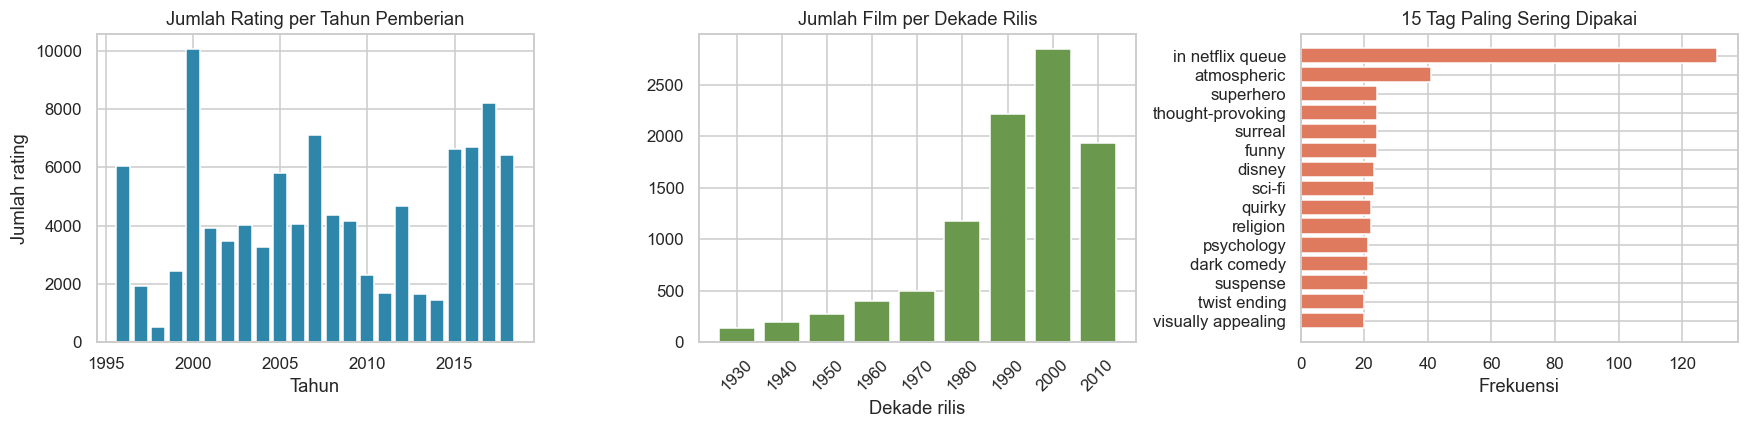

Rentang tahun pemberian rating : 1996 - 2018
Jumlah tag                     : 3,683
Tag unik                       : 1,589
Film yang memiliki tag         : 1,572 (16.1% katalog)
Pengguna yang pernah memberi tag: 58 dari 610


In [11]:
ratings_waktu = ratings.assign(tahun=pd.to_datetime(ratings.timestamp, unit='s').dt.year)
per_tahun = ratings_waktu.groupby('tahun').size()

movies_tahun = movies.assign(
    tahun_rilis=pd.to_numeric(movies.title.str.extract(r'\((\d{4})\)\s*$')[0], errors='coerce'))
film_dekade = (movies_tahun.dropna(subset=['tahun_rilis'])
                           .assign(dekade=lambda d: (d.tahun_rilis // 10 * 10).astype(int))
                           .query('dekade >= 1930')
                           .groupby('dekade').size())

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].bar(per_tahun.index, per_tahun.values, color='#2e86ab')
ax[0].set_title('Jumlah Rating per Tahun Pemberian')
ax[0].set_xlabel('Tahun')
ax[0].set_ylabel('Jumlah rating')

ax[1].bar(film_dekade.index.astype(str), film_dekade.values, color='#6a994e')
ax[1].set_title('Jumlah Film per Dekade Rilis')
ax[1].set_xlabel('Dekade rilis')
ax[1].tick_params(axis='x', rotation=45)

tag_teratas = tags.tag.str.lower().value_counts().head(15)
ax[2].barh(tag_teratas.index[::-1], tag_teratas.values[::-1], color='#e07a5f')
ax[2].set_title('15 Tag Paling Sering Dipakai')
ax[2].set_xlabel('Frekuensi')

plt.tight_layout()
simpan_gambar('fig_05_waktu_dan_tag.png')
plt.show()

print('Rentang tahun pemberian rating :', per_tahun.index.min(), '-', per_tahun.index.max())
print('Jumlah tag                     :', f'{len(tags):,}')
print('Tag unik                       :', f'{tags.tag.nunique():,}')
print('Film yang memiliki tag         :', f'{tags.movieId.nunique():,}',
      f'({tags.movieId.nunique()/n_movie_total*100:.1f}% katalog)')
print('Pengguna yang pernah memberi tag:', tags.userId.nunique(), f'dari {n_user}')

**Insight 5 — Rentang waktu 22 tahun menuntut evaluasi yang jujur, dan tag adalah sinyal konten tambahan yang berharga meski jarang.**

Rating terkumpul selama 22 tahun (1996–2018) dengan lonjakan pada beberapa
periode. Selera penonton dan komposisi katalog jelas berubah sepanjang waktu.
Karena itu proyek ini **tidak memakai pembagian data acak**, melainkan
**pembagian temporal per pengguna**: model dilatih dengan riwayat awal setiap
pengguna dan diuji pada tontonan mereka berikutnya. Skema ini meniru kondisi
produksi yang sesungguhnya, ketika sistem harus menebak masa depan dan bukan
menambal celah acak di masa lalu.

Tag hanya mencakup 16% katalog dan berasal dari 58 pengguna saja, tetapi isinya
jauh lebih spesifik daripada genre (`pixar`, `in netflix queue`, `atmospheric`,
`based on a book`). Tag dipakai sebagai **pelengkap**, bukan pengganti genre,
sehingga film tanpa tag tetap memperoleh representasi konten yang sah dari
genrenya.

---
# 4. Data Preparation

Delapan tahap berikut dijalankan **berurutan**. Urutan ini penting karena
keluaran satu tahap menjadi masukan tahap berikutnya. Setiap tahap disertai
alasan mengapa ia diperlukan.

| No | Tahap | Alasan |
|---|---|---|
| 1 | Verifikasi duplikat, nilai kosong, dan pemilihan berkas | Memastikan asumsi "satu pengguna–satu film–satu rating" benar-benar berlaku sebelum matriks interaksi dibentuk |
| 2 | Ekstraksi tahun rilis dan pembersihan judul | Judul mentah menempelkan tahun sehingga menyulitkan pencarian judul dan analisis per dekade |
| 3 | Parsing dan normalisasi genre | Genre tersimpan sebagai satu string dengan pemisah pipa dan harus diubah menjadi token yang dapat divektorkan |
| 4 | Agregasi dan normalisasi tag per film | Tag tersebar sebagai banyak baris per film dan harus diringkas menjadi satu dokumen teks per film |
| 5 | Pembentukan *content soup* dan vektorisasi TF-IDF | *Content-based filtering* memerlukan representasi numerik konten film |
| 6 | *Encoding* `userId` dan `movieId` menjadi indeks kontinu | Nilai id asli tidak berurutan sehingga tidak dapat langsung dipakai sebagai indeks matriks |
| 7 | Pembagian data secara temporal per pengguna | Menghindari kebocoran informasi masa depan dan meniru kondisi produksi |
| 8 | Pembentukan matriks interaksi, *candidate pool*, dan himpunan item relevan | Menyiapkan struktur data yang dipakai bersama oleh ketiga model dan oleh protokol evaluasi |

## Tahap 1 — Verifikasi Duplikat, Nilai Kosong, dan Pemilihan Berkas

**Mengapa diperlukan.** Seluruh model pada proyek ini mengasumsikan setiap sel
matriks interaksi berisi paling banyak satu rating. Jika terdapat pasangan
`(userId, movieId)` ganda, satu interaksi akan terhitung dua kali dan bobot
pembelajaran menjadi timpang. Verifikasi pada tahap 3.2 menunjukkan data sudah
bersih, sehingga tahap ini bersifat **penegasan (defensif)**: kode tetap
dijalankan agar jika suatu saat dataset diperbarui dan mengandung duplikat,
masalahnya langsung terdeteksi. Berkas `links.csv` juga dikeluarkan dari alur
karena tidak memuat informasi yang dipakai model.

In [12]:
jml_awal = len(ratings)
ratings = ratings.drop_duplicates(subset=['userId', 'movieId'], keep='last').reset_index(drop=True)
ratings = ratings.dropna(subset=['userId', 'movieId', 'rating'])
movies = movies.drop_duplicates(subset=['movieId']).reset_index(drop=True)

print(f'Rating sebelum verifikasi : {jml_awal:,}')
print(f'Rating setelah verifikasi : {len(ratings):,}  (dibuang: {jml_awal - len(ratings)})')
print(f'Film pada katalog         : {len(movies):,}')
print('Berkas yang dipakai       : ratings.csv, movies.csv, tags.csv')
print('Berkas yang tidak dipakai : links.csv (hanya berisi id eksternal IMDb/TMDB)')

Rating sebelum verifikasi : 100,836
Rating setelah verifikasi : 100,836  (dibuang: 0)
Film pada katalog         : 9,742
Berkas yang dipakai       : ratings.csv, movies.csv, tags.csv
Berkas yang tidak dipakai : links.csv (hanya berisi id eksternal IMDb/TMDB)


## Tahap 2 — Ekstraksi Tahun Rilis dan Pembersihan Judul

**Mengapa diperlukan.** Kolom `title` menggabungkan dua informasi berbeda dalam
satu string, misalnya `Toy Story (1995)`. Selama masih menyatu, tahun rilis
tidak dapat dianalisis sebagai angka dan pencarian judul menjadi rapuh karena
pengguna harus menuliskan tahunnya dengan tepat. Tahun rilis dipisahkan ke
kolom `tahun_rilis`, sedangkan judul bersih disimpan pada `judul_bersih` dan
dipakai sebagai antarmuka fungsi rekomendasi.

In [13]:
movies['tahun_rilis'] = pd.to_numeric(
    movies.title.str.extract(r'\((\d{4})\)\s*$')[0], errors='coerce')
movies['judul_bersih'] = movies.title.str.replace(r'\s*\(\d{4}\)\s*$', '', regex=True).str.strip()

print('Film tanpa tahun rilis yang dapat diekstrak:', int(movies.tahun_rilis.isna().sum()))
print('Rentang tahun rilis:', int(movies.tahun_rilis.min()), '-', int(movies.tahun_rilis.max()))
print()
print(movies[['movieId', 'title', 'judul_bersih', 'tahun_rilis']].head(5).to_string(index=False))

Film tanpa tahun rilis yang dapat diekstrak: 13
Rentang tahun rilis: 1902 - 2018

 movieId                              title                judul_bersih  tahun_rilis
       1                   Toy Story (1995)                   Toy Story       1995.0
       2                     Jumanji (1995)                     Jumanji       1995.0
       3            Grumpier Old Men (1995)            Grumpier Old Men       1995.0
       4           Waiting to Exhale (1995)           Waiting to Exhale       1995.0
       5 Father of the Bride Part II (1995) Father of the Bride Part II       1995.0


## Tahap 3 — Parsing dan Normalisasi Genre

**Mengapa diperlukan.** TF-IDF bekerja pada dokumen teks yang tersusun atas
token. Genre `Sci-Fi` dan `Film-Noir` mengandung tanda hubung, sedangkan
`(no genres listed)` sebenarnya bukan genre melainkan penanda ketiadaan
informasi. Tanpa normalisasi, `Sci-Fi` berisiko terpecah menjadi dua token
(`sci` dan `fi`) dan bercampur dengan token lain, sementara `(no genres listed)`
akan diperlakukan sebagai genre semu yang membuat 34 film saling mirip tanpa
dasar. Karena itu setiap genre diubah menjadi satu token tunggal huruf kecil
tanpa karakter khusus, dan penanda ketiadaan genre dihapus.

In [14]:
def normalkan_token(teks):
    """Mengubah frasa menjadi satu token tunggal: huruf kecil tanpa karakter non-alfanumerik."""
    return re.sub(r'[^a-z0-9]+', '', str(teks).lower())


movies['daftar_genre'] = (movies.genres
                          .str.replace('(no genres listed)', '', regex=False)
                          .str.split('|')
                          .apply(lambda g: [x for x in g if x]))
movies['token_genre'] = movies.daftar_genre.apply(
    lambda g: ' '.join(normalkan_token(x) for x in g))

print('Contoh hasil normalisasi genre:')
print(movies[['judul_bersih', 'genres', 'token_genre']].head(4).to_string(index=False))
print('\nContoh film tanpa genre (token menjadi string kosong):')
print(movies.loc[movies.token_genre == '', ['movieId', 'judul_bersih', 'genres']]
      .head(3).to_string(index=False))
print('\nJumlah film tanpa token genre:', int((movies.token_genre == '').sum()))

Contoh hasil normalisasi genre:
     judul_bersih                                      genres                                 token_genre
        Toy Story Adventure|Animation|Children|Comedy|Fantasy adventure animation children comedy fantasy
          Jumanji                  Adventure|Children|Fantasy                  adventure children fantasy
 Grumpier Old Men                              Comedy|Romance                              comedy romance
Waiting to Exhale                        Comedy|Drama|Romance                        comedy drama romance

Contoh film tanpa genre (token menjadi string kosong):
 movieId                                     judul_bersih             genres
  114335                                       La cravate (no genres listed)
  122888                                          Ben-hur (no genres listed)
  122896 Pirates of the Caribbean: Dead Men Tell No Tales (no genres listed)

Jumlah film tanpa token genre: 34


## Tahap 4 — Agregasi dan Normalisasi Tag per Film

**Mengapa diperlukan.** Pada `tags.csv`, satu film dapat muncul di banyak baris
karena diberi tag oleh beberapa pengguna, sedangkan TF-IDF membutuhkan tepat
**satu dokumen per film**. Seluruh tag milik satu film karena itu digabungkan
menjadi satu string. Frasa seperti `based on a book` dinormalkan menjadi satu
token utuh (`basedonabook`) supaya frasa tetap bermakna sebagai satu konsep dan
tidak pecah menjadi kata umum `based`, `on`, `a`, `book` yang menghubungkan
film-film yang sebenarnya tidak berkaitan. Tag sepanjang satu karakter dibuang
karena tidak informatif.

Frekuensi tag turut dipertahankan: bila lima pengguna menandai sebuah film
dengan `pixar`, token tersebut muncul lima kali sehingga TF-IDF memberinya bobot
lebih besar — mekanisme *term frequency* yang bekerja persis seperti pada teks
biasa.

In [15]:
tags_bersih = tags.copy()
tags_bersih['token_tag'] = tags_bersih.tag.apply(normalkan_token)
tags_bersih = tags_bersih[tags_bersih.token_tag.str.len() > 1]

tag_per_film = (tags_bersih.groupby('movieId')
                           .token_tag.apply(lambda s: ' '.join(s))
                           .rename('token_tag'))

movies = movies.merge(tag_per_film, on='movieId', how='left')
movies['token_tag'] = movies.token_tag.fillna('')

print(f'Baris tag sebelum pembersihan : {len(tags):,}')
print(f'Baris tag setelah pembersihan : {len(tags_bersih):,}')
print(f'Film yang memperoleh tag      : {int((movies.token_tag != "").sum()):,} '
      f'dari {len(movies):,} film ({(movies.token_tag != "").mean()*100:.1f}%)')
print('\nContoh agregasi tag:')
print(movies.loc[movies.token_tag != '', ['judul_bersih', 'token_tag']]
      .head(3).to_string(index=False))

Baris tag sebelum pembersihan : 3,683
Baris tag setelah pembersihan : 3,683
Film yang memperoleh tag      : 1,572 dari 9,742 film (16.1%)

Contoh agregasi tag:
    judul_bersih                                 token_tag
       Toy Story                           pixar pixar fun
         Jumanji fantasy magicboardgame robinwilliams game
Grumpier Old Men                                 moldy old


## Tahap 5 — Pembentukan *Content Soup* dan Vektorisasi TF-IDF

**Mengapa diperlukan.** *Content-based filtering* mengukur kemiripan antarfilm,
dan kemiripan hanya dapat dihitung apabila setiap film sudah berbentuk vektor
numerik. Token genre dan token tag digabung menjadi satu dokumen teks per film
yang lazim disebut *content soup*, lalu diubah menjadi matriks TF-IDF.

Dua keputusan penting pada tahap ini:

1. **Token genre digandakan dua kali.** Genre tersedia untuk hampir seluruh
   katalog, sedangkan tag hanya untuk 16% film. Tanpa penggandaan, film yang
   memiliki puluhan tag akan didominasi tag sehingga sinyal genrenya tenggelam,
   dan kemiripannya dengan film tanpa tag menjadi tidak sebanding. Penggandaan
   membuat genre tetap menjadi tulang punggung representasi, dengan tag sebagai
   pelengkap yang mempertajam.
2. **Pembobotan TF-IDF, bukan sekadar hitungan.** Bobot IDF menekan token yang
   muncul di mana-mana (`drama` ada pada 4.361 film sehingga hampir tidak
   membedakan apa pun) dan mengangkat token langka yang justru khas
   (`pixar`, `filmnoir`). Ini persis persoalan yang dirancang untuk diselesaikan
   oleh IDF.

Vektor tiap film kemudian dinormalisasi L2 agar hasil perkalian titik antardua
vektor **setara dengan *cosine similarity***, sehingga kemiripan dapat dihitung
lewat satu perkalian matriks yang efisien.

In [16]:
movies['content_soup'] = ((movies.token_genre + ' ') * 2 + movies.token_tag).str.strip()

print('Contoh content soup:')
for _, baris in movies.head(3).iterrows():
    print(f'  {baris.judul_bersih:<22} -> {baris.content_soup}')

vectorizer = TfidfVectorizer(token_pattern=r'\S+', min_df=1)
tfidf_semua = vectorizer.fit_transform(movies.content_soup)

print(f'\nDimensi matriks TF-IDF : {tfidf_semua.shape[0]:,} film x '
      f'{tfidf_semua.shape[1]:,} token')
print(f'Kepadatan matriks      : {tfidf_semua.nnz / np.prod(tfidf_semua.shape) * 100:.3f}%')
print(f'Contoh token kosakata  : {list(vectorizer.get_feature_names_out()[:12])}')

# Contoh bobot TF-IDF tertinggi pada satu film
contoh_idx = movies.index[movies.judul_bersih == 'Toy Story'][0]
baris = tfidf_semua[contoh_idx].toarray().ravel()
urut_bobot = np.argsort(-baris)[:6]
print('\nBobot TF-IDF tertinggi untuk "Toy Story":')
for j in urut_bobot:
    print(f'  {vectorizer.get_feature_names_out()[j]:<12} {baris[j]:.3f}')

Contoh content soup:
  Toy Story              -> adventure animation children comedy fantasy adventure animation children comedy fantasy pixar pixar fun
  Jumanji                -> adventure children fantasy adventure children fantasy fantasy magicboardgame robinwilliams game
  Grumpier Old Men       -> comedy romance comedy romance moldy old



Dimensi matriks TF-IDF : 9,742 film x 1,461 token
Kepadatan matriks      : 0.179%
Contoh token kosakata  : ['06oscarnominatedbestmovieanimation', '1900s', '1920s', '1950s', '1960s', '1970s', '1980s', '1990s', '2001like', '2danimation', '70mm', '80s']

Bobot TF-IDF tertinggi untuk "Toy Story":
  pixar        0.714
  fun          0.349
  animation    0.314
  children     0.307
  fantasy      0.293
  adventure    0.253


## Tahap 6 — *Encoding* `userId` dan `movieId` Menjadi Indeks Kontinu

**Mengapa diperlukan.** `userId` berkisar 1–610 sedangkan `movieId` melompat-lompat
hingga 193.609. Bila `movieId` dipakai langsung sebagai indeks matriks, akan
terbentuk matriks berukuran 610 × 193.610 yang 95% kolomnya kosong dan memboroskan
memori sekaligus komputasi. Setiap id karena itu dipetakan ke indeks berurutan
0..n−1, dan pemetaan baliknya disimpan agar hasil rekomendasi dapat diterjemahkan
kembali menjadi judul film yang terbaca manusia.

Katalog model dibatasi pada film yang **pernah muncul di data latih**. Film di
luar itu tidak mungkin dipelajari oleh *collaborative filtering* dan justru akan
menghasilkan vektor laten acak yang menyesatkan.

In [17]:
ratings = ratings.sort_values(['userId', 'timestamp']).reset_index(drop=True)

id_pengguna = np.sort(ratings.userId.unique())
pengguna_ke_idx = {uid: i for i, uid in enumerate(id_pengguna)}

print(f'Jumlah pengguna yang di-encode : {len(id_pengguna):,}')
print(f'Rentang userId asli            : {id_pengguna.min()} - {id_pengguna.max()}')
print(f'Rentang movieId asli           : {ratings.movieId.min()} - {ratings.movieId.max()}')
print('\nContoh pemetaan userId -> indeks:',
      {k: pengguna_ke_idx[k] for k in list(pengguna_ke_idx)[:5]})

Jumlah pengguna yang di-encode : 610
Rentang userId asli            : 1 - 610


Rentang movieId asli           : 1 - 193609

Contoh pemetaan userId -> indeks: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}


## Tahap 7 — Pembagian Data Secara Temporal per Pengguna

**Mengapa diperlukan.** Pembagian acak akan membuat model belajar dari rating
yang diberikan pengguna **pada tahun 2018** untuk memprediksi rating yang ia
berikan **pada tahun 2000**. Kebocoran waktu semacam itu melambungkan skor
evaluasi tetapi tidak pernah terjadi di dunia nyata, karena sistem produksi
selalu memprediksi ke depan.

Karena itu rating setiap pengguna diurutkan berdasarkan `timestamp`, lalu:

- **80% pertama** riwayat setiap pengguna → data latih penuh (`train_penuh`)
- **20% terakhir** riwayat setiap pengguna → **data uji** (`test`)

Pembagian dilakukan **per pengguna**, bukan pada satu titik waktu global,
supaya setiap pengguna tetap terwakili baik di data latih maupun data uji.

`train_penuh` kemudian dibagi lagi dengan cara yang sama menjadi `train_fit`
(80%) dan `validasi` (20%). **Seluruh penyetelan *hyperparameter* hanya
menggunakan `validasi`**; data uji sama sekali tidak disentuh sampai model final
terbentuk. Tanpa pemisahan ini, memilih *hyperparameter* berdasarkan skor uji
sama saja dengan melatih model pada data uji dan angka evaluasi menjadi terlalu
optimistis.

In [18]:
def bagi_temporal(df, porsi_latih=0.8):
    """Membagi rating tiap pengguna secara temporal: bagian awal untuk latih, akhir untuk uji."""
    df = df.sort_values(['userId', 'timestamp'])
    urutan = df.groupby('userId').cumcount()
    banyak = df.groupby('userId').movieId.transform('size')
    batas = np.ceil(banyak * porsi_latih)
    return df[urutan < batas].copy(), df[urutan >= batas].copy()


train_penuh, test = bagi_temporal(ratings, 0.8)
train_fit, validasi = bagi_temporal(train_penuh, 0.8)

ringkas = pd.DataFrame([
    {'subset': 'train_penuh', 'jumlah_rating': len(train_penuh), 'pengguna': train_penuh.userId.nunique(),
     'film': train_penuh.movieId.nunique(), 'porsi': len(train_penuh) / len(ratings)},
    {'subset': 'test', 'jumlah_rating': len(test), 'pengguna': test.userId.nunique(),
     'film': test.movieId.nunique(), 'porsi': len(test) / len(ratings)},
    {'subset': '  train_fit', 'jumlah_rating': len(train_fit), 'pengguna': train_fit.userId.nunique(),
     'film': train_fit.movieId.nunique(), 'porsi': len(train_fit) / len(ratings)},
    {'subset': '  validasi', 'jumlah_rating': len(validasi), 'pengguna': validasi.userId.nunique(),
     'film': validasi.movieId.nunique(), 'porsi': len(validasi) / len(ratings)},
])
ringkas['porsi'] = (ringkas.porsi * 100).round(1).astype(str) + '%'
print(ringkas.to_string(index=False))

print('\nVerifikasi tidak ada kebocoran waktu (waktu latih < waktu uji untuk tiap pengguna):')
maks_latih = train_penuh.groupby('userId').timestamp.max()
min_uji = test.groupby('userId').timestamp.min()
gabung = pd.concat([maks_latih.rename('maks_latih'), min_uji.rename('min_uji')], axis=1).dropna()
print(f'  Jumlah pengguna yang melanggar urutan waktu: {int((gabung.maks_latih > gabung.min_uji).sum())}')

     subset  jumlah_rating  pengguna  film porsi
train_penuh          80896       610  8246 80.2%
       test          19940       610  6243 19.8%
  train_fit          64960       610  7165 64.4%
   validasi          15936       610  5126 15.8%

Verifikasi tidak ada kebocoran waktu (waktu latih < waktu uji untuk tiap pengguna):


  Jumlah pengguna yang melanggar urutan waktu: 0


## Tahap 8 — Matriks Interaksi, *Candidate Pool*, dan Item Relevan

**Mengapa diperlukan.** Tahap ini menyiapkan tiga struktur data yang dipakai
bersama oleh seluruh model sehingga perbandingan antarmodel benar-benar setara.

1. **Matriks interaksi renggang (*sparse*).** Matriks 610 × 8.246 dalam bentuk
   padat memerlukan sekitar 40 MB, sementara hanya 1,7% selnya terisi. Format
   `csr_matrix` menyimpan yang terisi saja sehingga hemat memori dan mempercepat
   perkalian matriks.
2. ***Candidate pool*.** Film yang hanya memiliki kurang dari 5 rating pada data
   latih tidak memiliki bukti kolaboratif yang memadai; merekomendasikannya sama
   saja dengan menebak. Kumpulan kandidat karena itu dibatasi pada film dengan
   minimal 5 rating. Pembatasan ini **berlaku sama bagi ketiga model dan
   baseline**, sehingga perbandingan tetap adil dan bukan sekadar menguntungkan
   salah satu pendekatan.
3. **Himpunan item relevan.** Evaluasi peringkat membutuhkan definisi "benar"
   yang tegas. Sebuah film dianggap **relevan** bagi seorang pengguna apabila
   pada data uji ia memberi rating **≥ 4,0** — ambang yang sejalan dengan
   Insight 1, yaitu bahwa 4,0 adalah nilai penanda "film ini saya sukai".

In [19]:
katalog = np.sort(train_penuh.movieId.unique())
film_ke_idx = {mid: i for i, mid in enumerate(katalog)}
idx_ke_film = {i: mid for mid, i in film_ke_idx.items()}

N_PENGGUNA = len(id_pengguna)
N_FILM = len(katalog)

# Metadata film diselaraskan dengan urutan katalog
meta = movies.set_index('movieId').loc[katalog].reset_index()
tfidf = normalize(vectorizer.transform(meta.content_soup))   # normalisasi L2 -> cosine = dot product

# Matriks interaksi data latih
baris = train_penuh.userId.map(pengguna_ke_idx).to_numpy()
kolom = train_penuh.movieId.map(film_ke_idx).to_numpy()
matriks_latih = sp.csr_matrix((train_penuh.rating.to_numpy(float), (baris, kolom)),
                              shape=(N_PENGGUNA, N_FILM))
sudah_ditonton = np.zeros((N_PENGGUNA, N_FILM), dtype=bool)
sudah_ditonton[baris, kolom] = True

# Candidate pool: film dengan minimal 5 rating pada data latih
MIN_RATING_KANDIDAT = 5
jumlah_rating_film = np.asarray((matriks_latih > 0).sum(axis=0)).ravel()
pool = np.where(jumlah_rating_film >= MIN_RATING_KANDIDAT)[0]
pool_set = set(pool.tolist())

# Himpunan item relevan pada data uji
AMBANG_SUKA = 4.0
test_relevan = test[test.movieId.isin(film_ke_idx) & (test.rating >= AMBANG_SUKA)].copy()
test_relevan['idx_film'] = test_relevan.movieId.map(film_ke_idx)
test_relevan = test_relevan[test_relevan.idx_film.isin(pool_set)]
relevan_uji = {pengguna_ke_idx[u]: set(g.idx_film) for u, g in test_relevan.groupby('userId')}

meta['jumlah_rating_latih'] = jumlah_rating_film
meta['dalam_pool'] = np.isin(np.arange(N_FILM), pool)

print(f'Ukuran matriks interaksi     : {N_PENGGUNA:,} pengguna x {N_FILM:,} film')
print(f'Elemen terisi                : {matriks_latih.nnz:,} '
      f'({matriks_latih.nnz / (N_PENGGUNA * N_FILM) * 100:.2f}%)')
print(f'Memori format sparse (CSR)   : {matriks_latih.data.nbytes / 1024**2:.2f} MB')
print(f'Memori jika format padat     : {N_PENGGUNA * N_FILM * 8 / 1024**2:.2f} MB')
print(f'\nUkuran candidate pool        : {len(pool):,} film '
      f'({len(pool)/N_FILM*100:.1f}% katalog latih)')
print(f'Cakupan rating pool          : '
      f'{jumlah_rating_film[pool].sum() / jumlah_rating_film.sum() * 100:.1f}% dari rating data latih')
print(f'\nPengguna yang dapat dievaluasi: {len(relevan_uji):,} dari {N_PENGGUNA:,}')
print(f'Rata-rata item relevan/pengguna: '
      f'{np.mean([len(v) for v in relevan_uji.values()]):.1f}')

Ukuran matriks interaksi     : 610 pengguna x 8,246 film
Elemen terisi                : 80,896 (1.61%)
Memori format sparse (CSR)   : 0.62 MB
Memori jika format padat     : 38.38 MB

Ukuran candidate pool        : 3,039 film (36.9% katalog latih)
Cakupan rating pool          : 88.7% dari rating data latih

Pengguna yang dapat dievaluasi: 586 dari 610
Rata-rata item relevan/pengguna: 12.6


### Struktur Padanan untuk Data Validasi

Seluruh struktur di atas dibentuk ulang menggunakan `train_fit` dan `validasi`.
Padanan ini diperlukan agar penyetelan *hyperparameter* dinilai dengan protokol
yang persis sama dengan pengujian akhir, hanya pada data yang berbeda.

In [20]:
# Padanan struktur yang sama untuk data validasi (dipakai saat penyetelan hyperparameter)
baris_fit = train_fit.userId.map(pengguna_ke_idx).to_numpy()
kolom_fit = train_fit.movieId.map(film_ke_idx).to_numpy()
mask_fit = ~pd.isna(kolom_fit)
sudah_ditonton_fit = np.zeros((N_PENGGUNA, N_FILM), dtype=bool)
sudah_ditonton_fit[baris_fit, kolom_fit] = True

jumlah_rating_fit = np.asarray((sp.csr_matrix(
    (np.ones(len(train_fit)), (baris_fit, kolom_fit)), shape=(N_PENGGUNA, N_FILM)) > 0).sum(axis=0)).ravel()
pool_fit = np.where(jumlah_rating_fit >= MIN_RATING_KANDIDAT)[0]
pool_fit_set = set(pool_fit.tolist())

val_relevan = validasi[validasi.movieId.isin(film_ke_idx) & (validasi.rating >= AMBANG_SUKA)].copy()
val_relevan['idx_film'] = val_relevan.movieId.map(film_ke_idx)
val_relevan = val_relevan[val_relevan.idx_film.isin(pool_fit_set)]
relevan_validasi = {pengguna_ke_idx[u]: set(g.idx_film) for u, g in val_relevan.groupby('userId')}

print(f'Candidate pool validasi       : {len(pool_fit):,} film')
print(f'Pengguna pada evaluasi validasi: {len(relevan_validasi):,}')

Candidate pool validasi       : 2,600 film
Pengguna pada evaluasi validasi: 573


### Ringkasan Hasil Data Preparation

Setelah delapan tahap di atas, tersedia:

- `meta` — metadata 8.246 film pada katalog latih, lengkap dengan judul bersih,
  tahun rilis, token genre, token tag, dan jumlah rating.
- `tfidf` — matriks TF-IDF ternormalisasi berukuran 8.246 × 1.461 sebagai
  masukan *content-based filtering*.
- `matriks_latih`, `sudah_ditonton` — matriks interaksi dan penanda film yang
  sudah ditonton, sebagai masukan *collaborative filtering*.
- `train_fit` / `validasi` / `train_penuh` / `test` — pembagian data temporal
  berjenjang untuk penyetelan dan pengujian akhir.
- `pool`, `relevan_uji` — protokol evaluasi peringkat yang identik bagi semua model.

---
# 5. Modeling and Result

Empat sistem dibangun dan dibandingkan:

| Kode | Model | Pendekatan | Sinyal yang dipakai |
|---|---|---|---|
| **POP** | Popularitas | *Baseline* non-personal | Jumlah rating pada data latih |
| **CBF** | *Content-Based Filtering* | TF-IDF + *cosine similarity* | Genre dan tag film |
| **MF** | *Matrix Factorization* (SGD) | *Collaborative filtering* eksplisit | Nilai rating 0,5–5,0 |
| **iALS** | *Implicit Alternating Least Squares* | *Collaborative filtering* implisit | Interaksi "disukai" (rating ≥ 4) |

POP disertakan bukan sebagai kandidat solusi, melainkan sebagai **garis batas
kelayakan**: model personal apa pun yang tidak mampu mengungguli daftar film
terpopuler belum membuktikan dirinya mempelajari selera pengguna.

## 5.0 Fungsi Bantu Evaluasi

Fungsi berikut dipakai lebih dahulu pada tahap penyetelan *hyperparameter*
(menggunakan data validasi) dan dipakai ulang pada Bab 6 untuk pengujian akhir.
Formula lengkap tiap metrik beserta cara kerjanya dijelaskan pada Bab 6.

In [21]:
def evaluasi_ranking(skor, relevan, sudah, kandidat, K=10):
    """Menghitung Precision@K, Recall@K, NDCG@K, dan Coverage@K dari matriks skor.

    skor     : matriks (n_pengguna x n_film) berisi skor preferensi
    relevan  : dict {indeks_pengguna: himpunan indeks film relevan}
    sudah    : matriks boolean film yang sudah ditonton pada data latih
    kandidat : array indeks film yang boleh direkomendasikan (candidate pool)
    """
    presisi, recall, ndcg = [], [], []
    terekomendasi = set()
    diskon = 1 / np.log2(np.arange(2, K + 2))
    idcg_kumulatif = np.cumsum(diskon)

    for u, item_relevan in relevan.items():
        s = np.full(skor.shape[1], -np.inf)
        s[kandidat] = skor[u, kandidat].astype(float)
        s[sudah[u]] = -np.inf                       # jangan rekomendasikan yang sudah ditonton
        teratas = np.argpartition(-s, K)[:K]
        teratas = teratas[np.argsort(-s[teratas])]  # urutkan K teratas
        terekomendasi.update(teratas.tolist())

        hit = np.array([1.0 if i in item_relevan else 0.0 for i in teratas])
        presisi.append(hit.sum() / K)
        recall.append(hit.sum() / len(item_relevan))
        dcg = float((hit * diskon).sum())
        idcg = idcg_kumulatif[min(len(item_relevan), K) - 1]
        ndcg.append(dcg / idcg)

    return {
        f'Precision@{K}': float(np.mean(presisi)),
        f'Recall@{K}': float(np.mean(recall)),
        f'NDCG@{K}': float(np.mean(ndcg)),
        f'Coverage@{K}': len(terekomendasi) / len(kandidat),
    }


def evaluasi_rating(y_benar, y_prediksi):
    """Menghitung RMSE dan MAE untuk tugas prediksi nilai rating."""
    galat = np.asarray(y_benar, dtype=float) - np.asarray(y_prediksi, dtype=float)
    return {'RMSE': float(np.sqrt((galat ** 2).mean())), 'MAE': float(np.abs(galat).mean())}


print('Fungsi bantu evaluasi siap digunakan.')

Fungsi bantu evaluasi siap digunakan.


---
## 5.1 Model 1 — Content-Based Filtering

### Cara kerja

Setiap film sudah direpresentasikan sebagai vektor TF-IDF ternormalisasi
$\mathbf{v}_i \in \mathbb{R}^{1461}$ (Tahap 5 persiapan data). Kemiripan dua
film diukur dengan ***cosine similarity***:

$$\text{sim}(i, j) = \cos(\theta) = \frac{\mathbf{v}_i \cdot \mathbf{v}_j}{\lVert \mathbf{v}_i \rVert \, \lVert \mathbf{v}_j \rVert}$$

Karena seluruh vektor sudah dinormalisasi L2 ($\lVert \mathbf{v} \rVert = 1$),
penyebutnya bernilai 1 sehingga kemiripan cukup dihitung sebagai perkalian titik.
Nilainya berkisar 0 (tidak berbagi token sama sekali) sampai 1 (representasi
konten identik).

Model ini dipakai dalam dua mode.

**Mode A — rekomendasi item-ke-item.** Diberikan satu film, sistem menampilkan
N film paling mirip. Inilah mekanisme di balik kolom "karena Anda menonton …".

**Mode B — rekomendasi personal.** Profil pengguna $\mathbf{p}_u$ dibangun
sebagai rata-rata berbobot vektor konten seluruh film yang ia sukai (rating ≥ 4)
pada data latih, dengan rating sebagai bobot:

$$\mathbf{p}_u = \frac{\sum_{i \in \mathcal{L}_u} r_{ui} \, \mathbf{v}_i}{\left\lVert \sum_{i \in \mathcal{L}_u} r_{ui} \, \mathbf{v}_i \right\rVert}$$

dengan $\mathcal{L}_u$ himpunan film yang disukai pengguna $u$. Skor sebuah film
kandidat adalah $\text{skor}(u, i) = \mathbf{p}_u \cdot \mathbf{v}_i$.

In [22]:
judul_ke_idx = {judul: i for i, judul in enumerate(meta.judul_bersih)}


def rekomendasi_serupa(judul, top_n=10, min_rating=5):
    """Mode A: mencari film yang kontennya paling mirip dengan judul yang diberikan."""
    if judul not in judul_ke_idx:
        kandidat = [j for j in judul_ke_idx if judul.lower() in j.lower()][:5]
        raise KeyError(f'Judul "{judul}" tidak ditemukan. Saran: {kandidat}')

    i = judul_ke_idx[judul]
    kemiripan = np.asarray((tfidf[i] @ tfidf.T).todense()).ravel()
    kemiripan[i] = -1                                                  # jangan rekomendasikan dirinya
    kemiripan[meta.jumlah_rating_latih.to_numpy() < min_rating] = -1   # buang film tanpa bukti minat

    # Skor kemiripan banyak yang seri; popularitas dipakai sebagai pemecah seri
    urutan = np.lexsort((-meta.jumlah_rating_latih.to_numpy(), -kemiripan))[:top_n]
    hasil = meta.iloc[urutan][['judul_bersih', 'tahun_rilis', 'genres', 'jumlah_rating_latih']].copy()
    hasil.insert(0, 'peringkat', np.arange(1, len(urutan) + 1))
    hasil['kemiripan'] = kemiripan[urutan].round(3)
    return hasil.reset_index(drop=True)


for judul_uji in ['Toy Story', 'Godfather, The', 'Silence of the Lambs, The']:
    asal = meta.loc[judul_ke_idx[judul_uji]]
    print('=' * 100)
    print(f'TOP-10 FILM MIRIP DENGAN: {judul_uji} ({int(asal.tahun_rilis)})  |  genre: {asal.genres}')
    print('=' * 100)
    print(rekomendasi_serupa(judul_uji).to_string(index=False))
    print()

TOP-10 FILM MIRIP DENGAN: Toy Story (1995)  |  genre: Adventure|Animation|Children|Comedy|Fantasy
 peringkat                            judul_bersih  tahun_rilis                                            genres  jumlah_rating_latih  kemiripan
         1                           Bug's Life, A       1998.0               Adventure|Animation|Children|Comedy                   79      0.839
         2                             Toy Story 2       1999.0       Adventure|Animation|Children|Comedy|Fantasy                   85      0.744
         3                          Monsters, Inc.       2001.0       Adventure|Animation|Children|Comedy|Fantasy                  119      0.607
         4                                    Antz       1998.0       Adventure|Animation|Children|Comedy|Fantasy                   36      0.607
         5               Emperor's New Groove, The       2000.0       Adventure|Animation|Children|Comedy|Fantasy                   33      0.607
         6                

**Pembacaan hasil Mode A.** Sistem menempatkan *A Bug's Life*, *Toy Story 2*,
dan *Monsters, Inc.* sebagai film termirip dengan *Toy Story* — ketiganya
animasi keluarga produksi Pixar, dan dua di antaranya terhubung lewat tag
`pixar`, bukan sekadar lewat genre. Untuk *The Godfather*, sistem
mengembalikan *Goodfellas*, *Casino*, dan *Donnie Brasco* dengan kemiripan
1,000: keempatnya berbagi kombinasi genre `Crime|Drama` yang persis sama.
Nilai kemiripan sempurna ini sekaligus memperlihatkan **keterbatasan mendasar**
pendekatan konten pada dataset ini — metadata tidak cukup halus untuk
membedakan film-film dalam kombinasi genre yang sama, sehingga banyak skor
yang seri dan urutan akhirnya ditentukan pemecah seri.

In [23]:
def matriks_konten(kolom):
    """Membangun matriks TF-IDF ternormalisasi dari sebuah kolom teks pada meta."""
    vec = TfidfVectorizer(token_pattern=r'\S+')
    return normalize(vec.fit_transform(meta[kolom].fillna('')))


def bangun_skor_cbf(data_latih, matriks_isi=None, gunakan_deviasi=False, ambang=AMBANG_SUKA):
    """Menghasilkan matriks skor CBF (n_pengguna x n_film) dari profil konten pengguna.

    gunakan_deviasi=False : profil dibangun hanya dari film yang disukai (rating >= ambang),
                            dengan rating sebagai bobot.
    gunakan_deviasi=True  : seluruh rating dipakai dengan bobot (rating - rata-rata pengguna),
                            sehingga film yang tidak disukai memberi kontribusi negatif.
    """
    X = tfidf if matriks_isi is None else matriks_isi
    if gunakan_deviasi:
        dipakai = data_latih
        bobot = data_latih.rating - data_latih.groupby('userId').rating.transform('mean')
    else:
        dipakai = data_latih[data_latih.rating >= ambang]
        bobot = dipakai.rating
    W = sp.csr_matrix((bobot.to_numpy(float),
                       (dipakai.userId.map(pengguna_ke_idx), dipakai.movieId.map(film_ke_idx))),
                      shape=(N_PENGGUNA, N_FILM))
    profil = normalize(W @ X)                 # rata-rata berbobot, lalu dinormalisasi L2
    return np.asarray((profil @ X.T).todense())


print('Fungsi pembentuk profil dan skor CBF siap.')

Fungsi pembentuk profil dan skor CBF siap.


### Pemilihan varian representasi konten berdasarkan data validasi

Sebelum model CBF final ditetapkan, tiga varian dibandingkan pada **data
validasi** agar keputusan rancangan tidak mencemari angka pengujian akhir:

1. **Genre saja** — hanya token genre yang dipakai.
2. **Genre + tag** — representasi gabungan hasil Tahap 5 persiapan data.
3. **Genre + tag dengan profil deviasi** — profil dibangun dari seluruh rating
   dengan bobot $r_{ui} - \bar{r}_u$, sehingga film yang dinilai di bawah
   kebiasaan pengguna memberi kontribusi negatif dan aktif menjauhkan
   rekomendasi dari selera yang tidak disukai.

In [24]:
meta['konten_genre_saja'] = meta.token_genre
tfidf_genre_saja = matriks_konten('konten_genre_saja')

varian_cbf = {
    'Genre saja': dict(matriks_isi=tfidf_genre_saja, gunakan_deviasi=False),
    'Genre + tag': dict(matriks_isi=tfidf, gunakan_deviasi=False),
    'Genre + tag, profil deviasi': dict(matriks_isi=tfidf, gunakan_deviasi=True),
}

hasil_varian = []
for nama, argumen in varian_cbf.items():
    skor_v = bangun_skor_cbf(train_fit, **argumen)
    metrik = evaluasi_ranking(skor_v, relevan_validasi, sudah_ditonton_fit, pool_fit, K=10)
    hasil_varian.append({'Varian': nama, **metrik})

tabel_varian_cbf = pd.DataFrame(hasil_varian).sort_values('NDCG@10', ascending=False).reset_index(drop=True)
print('--- Perbandingan varian CBF pada data validasi ---')
print(tabel_varian_cbf.round(4).to_string(index=False))

varian_terpilih = tabel_varian_cbf.iloc[0].Varian
print(f'\nVarian terpilih: {varian_terpilih}')

--- Perbandingan varian CBF pada data validasi ---
                     Varian  Precision@10  Recall@10  NDCG@10  Coverage@10
                 Genre saja        0.0101     0.0104   0.0143       0.4400
Genre + tag, profil deviasi        0.0098     0.0104   0.0109       0.5858
                Genre + tag        0.0073     0.0073   0.0107       0.3615

Varian terpilih: Genre saja


**Pembacaan hasil ablasi.** Varian **genre saja** justru unggul tipis untuk
rekomendasi personal. Penjelasannya masuk akal: tag hanya tersedia pada 16%
katalog dan berasal dari 58 pengguna. Ketika profil seseorang kebetulan
terbentuk dari beberapa film bertag banyak, profil itu ikut condong ke kosakata
tag yang sempit dan tidak dimiliki mayoritas kandidat, sehingga pencocokan
menjadi kurang stabil. Varian profil deviasi memberi cakupan katalog terluas
tetapi tidak lebih tepat.

Yang lebih penting: **ketiga varian sama-sama berada jauh di bawah baseline
populer**. Ini petunjuk awal bahwa keterbatasan CBF di sini bukan soal cara
menyusun profil pengguna, melainkan soal resolusi metadata yang tersedia —
dugaan yang akan dikonfirmasi pada Bab 6.

Karena itu ditetapkan pembagian peran berikut:

- **Mode A (item-ke-item)** tetap memakai representasi **genre + tag**, karena
  tag menghasilkan kemiripan yang lebih kaya dan penjelasan yang lebih meyakinkan
  ("mirip karena sama-sama bertag *pixar*").
- **Mode B (rekomendasi personal)** memakai varian yang menang pada data
  validasi, yaitu representasi yang tercetak di atas.

In [25]:
skor_cbf = bangun_skor_cbf(train_penuh, **varian_cbf[varian_terpilih])

profil_kosong = int((np.abs(skor_cbf).sum(axis=1) == 0).sum())
print('Dimensi matriks skor CBF :', skor_cbf.shape)
print(f'Rentang skor             : {skor_cbf.min():.3f} sampai {skor_cbf.max():.3f}')
print('Pengguna tanpa profil    :', profil_kosong)

Dimensi matriks skor CBF :

 (610, 8246)
Rentang skor             : 0.000 sampai 1.000
Pengguna tanpa profil    : 3


---
## 5.2 Model 2 — Collaborative Filtering dengan *Matrix Factorization* (SGD)

### Cara kerja

*Matrix factorization* mengasumsikan matriks rating $R$ berukuran
$610 \times 8.246$ dapat dihampiri oleh perkalian dua matriks berdimensi jauh
lebih kecil: matriks faktor pengguna $P \in \mathbb{R}^{610 \times k}$ dan
matriks faktor film $Q \in \mathbb{R}^{8.246 \times k}$. Setiap pengguna dan
setiap film diwakili satu vektor laten berdimensi $k$ yang dipelajari langsung
dari data — tidak ada yang memberi tahu model bahwa suatu dimensi berarti
"kadar aksi" atau "kadar drama"; makna itu muncul sendiri dari pola rating.

Prediksi rating memakai bentuk **berbias** (Koren et al., 2009):

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u^{\top} \mathbf{q}_i$$

- $\mu$ — rata-rata rating global, titik acuan
- $b_u$ — bias pengguna, menangkap kecenderungan menilai murah hati atau pelit (Insight 1)
- $b_i$ — bias film, menangkap kualitas rata-rata film (Insight 4)
- $\mathbf{p}_u^{\top}\mathbf{q}_i$ — kecocokan selera personal

Parameter dicari dengan meminimumkan galat kuadrat berregularisasi **hanya pada
rating yang benar-benar teramati**:

$$\min_{p,q,b} \sum_{(u,i) \in \mathcal{K}} \left( r_{ui} - \hat{r}_{ui} \right)^2 + \lambda \left( \lVert \mathbf{p}_u \rVert^2 + \lVert \mathbf{q}_i \rVert^2 + b_u^2 + b_i^2 \right)$$

Optimasi dilakukan dengan *stochastic gradient descent*. Untuk setiap rating
teramati, galat $e_{ui} = r_{ui} - \hat{r}_{ui}$ dihitung lalu seluruh parameter
terkait diperbarui berlawanan arah gradien:

$$b_u \leftarrow b_u + \eta\,(e_{ui} - \lambda b_u), \qquad b_i \leftarrow b_i + \eta\,(e_{ui} - \lambda b_i)$$
$$\mathbf{p}_u \leftarrow \mathbf{p}_u + \eta\,(e_{ui}\,\mathbf{q}_i - \lambda \mathbf{p}_u), \qquad \mathbf{q}_i \leftarrow \mathbf{q}_i + \eta\,(e_{ui}\,\mathbf{p}_u - \lambda \mathbf{q}_i)$$

dengan $\eta$ laju pembelajaran dan $\lambda$ kekuatan regularisasi.

In [26]:
def latih_mf(data_latih, n_faktor=50, reg=0.05, lr=0.01, epochs=25,
             data_pantau=None, seed=SEED, verbose=False):
    """Melatih biased matrix factorization dengan stochastic gradient descent."""
    u_idx = data_latih.userId.map(pengguna_ke_idx).to_numpy()
    i_idx = data_latih.movieId.map(film_ke_idx).to_numpy()
    r = data_latih.rating.to_numpy(float)

    rng = np.random.default_rng(seed)
    P = rng.normal(0, 0.05, (N_PENGGUNA, n_faktor))
    Q = rng.normal(0, 0.05, (N_FILM, n_faktor))
    bu = np.zeros(N_PENGGUNA)
    bi = np.zeros(N_FILM)
    mu = r.mean()

    if data_pantau is not None:
        pantau = data_pantau[data_pantau.movieId.isin(film_ke_idx)]
        pu_idx = pantau.userId.map(pengguna_ke_idx).to_numpy()
        pi_idx = pantau.movieId.map(film_ke_idx).to_numpy()
        pr = pantau.rating.to_numpy(float)

    urutan = np.arange(len(r))
    riwayat = []
    for epoch in range(1, epochs + 1):
        rng.shuffle(urutan)
        for t in urutan:
            u, i, nilai = u_idx[t], i_idx[t], r[t]
            p_u = P[u].copy()
            q_i = Q[i]
            galat = nilai - (mu + bu[u] + bi[i] + p_u @ q_i)
            bu[u] += lr * (galat - reg * bu[u])
            bi[i] += lr * (galat - reg * bi[i])
            P[u] += lr * (galat * q_i - reg * p_u)
            Q[i] += lr * (galat * p_u - reg * q_i)

        pred_latih = np.clip(mu + bu[u_idx] + bi[i_idx] + np.sum(P[u_idx] * Q[i_idx], axis=1), 0.5, 5.0)
        catatan = {'epoch': epoch, 'rmse_latih': evaluasi_rating(r, pred_latih)['RMSE']}
        if data_pantau is not None:
            pred_pantau = np.clip(mu + bu[pu_idx] + bi[pi_idx] + np.sum(P[pu_idx] * Q[pi_idx], axis=1), 0.5, 5.0)
            catatan['rmse_pantau'] = evaluasi_rating(pr, pred_pantau)['RMSE']
        riwayat.append(catatan)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print('   ', {k: (round(v, 4) if isinstance(v, float) else v) for k, v in catatan.items()})

    return {'P': P, 'Q': Q, 'bu': bu, 'bi': bi, 'mu': mu, 'riwayat': pd.DataFrame(riwayat),
            'params': {'n_faktor': n_faktor, 'reg': reg, 'lr': lr, 'epochs': epochs}}


def skor_matriks_mf(model):
    """Menghasilkan matriks skor prediksi rating untuk seluruh pasangan pengguna-film."""
    return model['mu'] + model['bu'][:, None] + model['bi'][None, :] + model['P'] @ model['Q'].T


def prediksi_mf(model, data):
    """Memprediksi rating untuk sekumpulan pasangan (userId, movieId).

    Film yang tidak ada pada katalog latih (cold-start) diprediksi dengan
    cadangan mu + b_u, yaitu tebakan terbaik ketika film belum punya riwayat.
    """
    u = data.userId.map(pengguna_ke_idx).to_numpy()
    ada = data.movieId.isin(film_ke_idx).to_numpy()
    i = data.movieId.map(film_ke_idx).fillna(0).astype(int).to_numpy()
    penuh = model['mu'] + model['bu'][u] + model['bi'][i] + np.sum(model['P'][u] * model['Q'][i], axis=1)
    cadangan = model['mu'] + model['bu'][u]
    return np.clip(np.where(ada, penuh, cadangan), 0.5, 5.0)


print('Fungsi pelatihan Matrix Factorization siap.')

Fungsi pelatihan Matrix Factorization siap.


### Penyetelan *hyperparameter* MF pada data validasi

Empat kombinasi diuji untuk melihat pengaruh jumlah faktor laten $k$ dan
kekuatan regularisasi $\lambda$. Model dilatih pada `train_fit` dan dinilai pada
`validasi` — **data uji sama sekali tidak dilibatkan**.

In [27]:
grid_mf = [
    {'n_faktor': 20, 'reg': 0.05, 'lr': 0.01},
    {'n_faktor': 50, 'reg': 0.05, 'lr': 0.01},
    {'n_faktor': 50, 'reg': 0.10, 'lr': 0.01},
    {'n_faktor': 100, 'reg': 0.05, 'lr': 0.01},
]

waktu_mulai = time.time()
hasil_grid_mf = []
riwayat_terbaik = None
for konf in grid_mf:
    model_uji = latih_mf(train_fit, epochs=25, data_pantau=validasi, **konf)
    rmse_val = model_uji['riwayat'].rmse_pantau.to_numpy()
    epoch_terbaik = int(np.argmin(rmse_val)) + 1
    hasil_grid_mf.append({**konf, 'rmse_latih': model_uji['riwayat'].rmse_latih.iloc[-1],
                          'rmse_validasi': float(rmse_val.min()), 'epoch_terbaik': epoch_terbaik})
    print(f"k={konf['n_faktor']:>3} reg={konf['reg']:.2f} -> "
          f"RMSE validasi terbaik {rmse_val.min():.4f} pada epoch {epoch_terbaik} "
          f"({time.time() - waktu_mulai:.0f} detik)")
    if riwayat_terbaik is None or rmse_val.min() < riwayat_terbaik[1]:
        riwayat_terbaik = (model_uji['riwayat'], float(rmse_val.min()), konf)

tabel_grid_mf = pd.DataFrame(hasil_grid_mf).sort_values('rmse_validasi').reset_index(drop=True)
print('\n--- Hasil penyetelan Matrix Factorization ---')
print(tabel_grid_mf.round(4).to_string(index=False))

konfigurasi_mf = tabel_grid_mf.iloc[0]
print(f"\nKonfigurasi terpilih: k={int(konfigurasi_mf.n_faktor)}, "
      f"reg={konfigurasi_mf.reg}, lr={konfigurasi_mf.lr}, "
      f"epochs={int(konfigurasi_mf.epoch_terbaik)}")

k= 20 reg=0.05 -> RMSE validasi terbaik 0.8777 pada epoch 25 (23 detik)


k= 50 reg=0.05 -> RMSE validasi terbaik 0.8755 pada epoch 24 (47 detik)


k= 50 reg=0.10 -> RMSE validasi terbaik 0.8803 pada epoch 20 (69 detik)


k=100 reg=0.05 -> RMSE validasi terbaik 0.8689 pada epoch 25 (93 detik)

--- Hasil penyetelan Matrix Factorization ---
 n_faktor  reg   lr  rmse_latih  rmse_validasi  epoch_terbaik
      100 0.05 0.01      0.5753         0.8689             25
       50 0.05 0.01      0.6378         0.8755             24
       20 0.05 0.01      0.7134         0.8777             25
       50 0.10 0.01      0.7645         0.8803             20

Konfigurasi terpilih: k=100, reg=0.05, lr=0.01, epochs=25


### Kurva Pembelajaran Konfigurasi Terbaik

Riwayat RMSE per epoch dari konfigurasi dengan skor validasi terbaik
divisualisasikan untuk memeriksa gejala *overfitting* sekaligus menentukan
jumlah epoch model final.

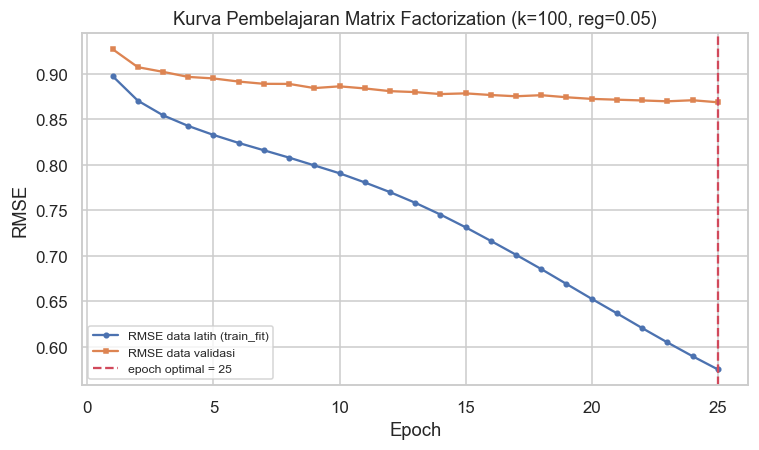

RMSE latih pada epoch terakhir   : 0.5753
RMSE validasi pada epoch terakhir: 0.8689
RMSE validasi terbaik            : 0.8689


In [28]:
riwayat, _, konf_kurva = riwayat_terbaik
plt.figure(figsize=(7, 4.2))
plt.plot(riwayat.epoch, riwayat.rmse_latih, marker='o', ms=3, label='RMSE data latih (train_fit)')
plt.plot(riwayat.epoch, riwayat.rmse_pantau, marker='s', ms=3, label='RMSE data validasi')
epoch_opt = int(riwayat.rmse_pantau.idxmin()) + 1
plt.axvline(epoch_opt, color='#d1495b', ls='--',
            label=f'epoch optimal = {epoch_opt}')
plt.title(f"Kurva Pembelajaran Matrix Factorization "
          f"(k={konf_kurva['n_faktor']}, reg={konf_kurva['reg']})")
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend(fontsize=8)
plt.tight_layout()
simpan_gambar('fig_06_kurva_pembelajaran_mf.png')
plt.show()

print('RMSE latih pada epoch terakhir   :', round(riwayat.rmse_latih.iloc[-1], 4))
print('RMSE validasi pada epoch terakhir:', round(riwayat.rmse_pantau.iloc[-1], 4))
print('RMSE validasi terbaik            :', round(riwayat.rmse_pantau.min(), 4))

**Pembacaan kurva pembelajaran.** RMSE data latih terus menurun tajam sepanjang
pelatihan hingga menyentuh sekitar 0,58, sementara RMSE validasi turun cepat pada
epoch-epoch awal lalu mendatar di kisaran 0,87. Jarak yang terus melebar di antara
keduanya adalah tanda *overfitting* klasik: model mulai menghafal rating individual
alih-alih mempelajari pola selera yang dapat digeneralisasi.

Jumlah epoch model final ditetapkan pada titik RMSE validasi terendah, bukan pada
epoch terakhir. Untuk konfigurasi terpilih kedua titik itu kebetulan berimpit,
sehingga seluruh 25 epoch tetap dipakai; sedangkan pada konfigurasi
k=50 reg=0,10 titik terendah muncul lebih awal, yaitu pada epoch 20.

In [29]:
model_mf = latih_mf(train_penuh,
                    n_faktor=int(konfigurasi_mf.n_faktor),
                    reg=float(konfigurasi_mf.reg),
                    lr=float(konfigurasi_mf.lr),
                    epochs=int(konfigurasi_mf.epoch_terbaik),
                    data_pantau=None, verbose=False)
skor_mf = skor_matriks_mf(model_mf)

print('Model MF final selesai dilatih pada train_penuh.')
print('Parameter:', model_mf['params'])
print(f"Rata-rata global (mu)      : {model_mf['mu']:.4f}")
print(f"Rentang bias pengguna (b_u): {model_mf['bu'].min():.3f} sampai {model_mf['bu'].max():.3f}")
print(f"Rentang bias film (b_i)    : {model_mf['bi'].min():.3f} sampai {model_mf['bi'].max():.3f}")

# Bias film tertinggi dan terendah - pemeriksaan kewajaran hasil belajar model
urut_bias = np.argsort(-model_mf['bi'])
print('\nLima film dengan bias tertinggi (disukai lintas selera):')
print(meta.iloc[urut_bias[:5]][['judul_bersih', 'jumlah_rating_latih']]
      .assign(bias=model_mf['bi'][urut_bias[:5]].round(3)).to_string(index=False))

Model MF final selesai dilatih pada train_penuh.
Parameter: {'n_faktor': 100, 'reg': 0.05, 'lr': 0.01, 'epochs': 25}
Rata-rata global (mu)      : 3.5141
Rentang bias pengguna (b_u): -2.088 sampai 1.276
Rentang bias film (b_i)    : -1.703 sampai 0.931

Lima film dengan bias tertinggi (disukai lintas selera):
                judul_bersih  jumlah_rating_latih  bias
                     Yojimbo                   11 0.931
              Paths of Glory                    8 0.905
Guess Who's Coming to Dinner                    9 0.880
             His Girl Friday                   12 0.878
          Lawrence of Arabia                   39 0.871


**Catatan penting atas bias film.** Lima film dengan bias tertinggi seluruhnya
adalah film klasik yang hanya memiliki 8–39 rating. Regularisasi $\lambda = 0{,}05$
— nilai yang dipilih karena memberikan RMSE validasi terbaik — ternyata terlalu
lemah untuk menarik estimasi film berdata sedikit kembali ke rata-rata global.
Akibatnya film-film tersebut memperoleh prediksi rating yang sangat tinggi dan
akan membanjiri daftar rekomendasi.

Inilah pertama kalinya terlihat bahwa **kriteria pemilihan berbasis RMSE dapat
merugikan kualitas peringkat**: RMSE dihitung hanya pada rating yang teramati,
sehingga tidak pernah menghukum model karena menempatkan film asing di puncak
daftar. Konsekuensi konkretnya akan terlihat pada keluaran top-N di bagian 5.5
dan pada angka Precision@10 di Bab 6.

---
## 5.3 Model 3 — Collaborative Filtering dengan *Implicit ALS*

### Mengapa model kedua ini diperlukan

*Matrix factorization* pada 5.2 dilatih untuk **menebak angka rating**. Padahal
yang benar-benar dibutuhkan sistem rekomendasi adalah **mengurutkan** film:
yang penting sepuluh judul teratas tepat, bukan apakah taksirannya 4,3 atau 4,1.
Kedua tujuan itu tidak identik. Model yang mahir menebak angka bisa saja
menempatkan film asing berprediksi 4,6 di atas film yang benar-benar akan
ditonton pengguna, karena galat pada film asing tidak pernah dihukum — film
tersebut memang tidak ada pada data teramati.

*Implicit ALS* (Hu, Koren & Volinsky, 2008) menyerang persoalan dari sisi yang
berbeda. Rating diterjemahkan menjadi **sinyal biner**: $p_{ui} = 1$ bila
pengguna memberi rating ≥ 4 (menyukai), dan $p_{ui} = 0$ untuk **seluruh
pasangan lain** — termasuk film yang belum pernah dilihat. Setiap pengamatan
diberi bobot keyakinan

$$c_{ui} = 1 + \alpha \, p_{ui}$$

sehingga interaksi yang teramati ditimbang $1 + \alpha$ sedangkan yang tidak
teramati tetap ikut dihitung dengan bobot 1. Perbedaan inilah kuncinya: model
**mempelajari pasangan negatif juga**, sehingga tahu bahwa film populer yang
dilewatkan pengguna kemungkinan besar memang tidak diminati.

Fungsi objektifnya mencakup seluruh $610 \times 8.246$ pasangan:

$$\min_{x,y} \sum_{u,i} c_{ui}\left(p_{ui} - \mathbf{x}_u^{\top}\mathbf{y}_i\right)^2 + \lambda\left(\sum_u \lVert \mathbf{x}_u \rVert^2 + \sum_i \lVert \mathbf{y}_i \rVert^2\right)$$

Menjumlahkan lima juta pasangan pada tiap langkah SGD jelas tidak praktis.
Solusinya adalah *alternating least squares*: bila $Y$ dianggap tetap, fungsi
objektif menjadi kuadratik terhadap $X$ dan memiliki solusi tertutup

$$\mathbf{x}_u = \left(Y^{\top}Y + Y^{\top}(C^u - I)Y + \lambda I\right)^{-1} Y^{\top} C^u \mathbf{p}(u)$$

lalu perannya ditukar untuk memperbarui $Y$. Suku $Y^{\top}Y$ dihitung **satu
kali** untuk semua pengguna, sedangkan $Y^{\top}(C^u - I)Y$ hanya melibatkan
film yang benar-benar berinteraksi dengan pengguna $u$. Dengan trik itu, satu
iterasi ALS hanya berbiaya sepersekian detik untuk data ini.

In [30]:
def latih_ials(data_latih, n_faktor=32, reg=2.0, alpha=10.0, iterasi=15,
               ambang=AMBANG_SUKA, seed=SEED):
    """Melatih implicit ALS (Hu, Koren & Volinsky 2008) dari interaksi 'disukai'."""
    positif = data_latih[data_latih.rating >= ambang]
    C = sp.csr_matrix((np.ones(len(positif)),
                       (positif.userId.map(pengguna_ke_idx), positif.movieId.map(film_ke_idx))),
                      shape=(N_PENGGUNA, N_FILM))
    C_pengguna, C_film = C.tocsr(), C.tocsc()

    rng = np.random.default_rng(seed)
    X = rng.normal(0, 0.01, (N_PENGGUNA, n_faktor))
    Y = rng.normal(0, 0.01, (N_FILM, n_faktor))
    I_reg = reg * np.eye(n_faktor)

    for _ in range(iterasi):
        YtY = Y.T @ Y + I_reg                     # dihitung sekali untuk semua pengguna
        for u in range(N_PENGGUNA):
            item = C_pengguna.indices[C_pengguna.indptr[u]:C_pengguna.indptr[u + 1]]
            if len(item) == 0:
                X[u] = 0
                continue
            Yi = Y[item]
            A = YtY + alpha * (Yi.T @ Yi)         # Y^T Y + Y^T (C^u - I) Y + lambda I
            b = (1 + alpha) * Yi.sum(axis=0)      # Y^T C^u p(u)
            X[u] = np.linalg.solve(A, b)

        XtX = X.T @ X + I_reg                     # dihitung sekali untuk semua film
        for i in range(N_FILM):
            pengguna = C_film.indices[C_film.indptr[i]:C_film.indptr[i + 1]]
            if len(pengguna) == 0:
                Y[i] = 0
                continue
            Xu = X[pengguna]
            A = XtX + alpha * (Xu.T @ Xu)
            b = (1 + alpha) * Xu.sum(axis=0)
            Y[i] = np.linalg.solve(A, b)

    return {'X': X, 'Y': Y,
            'params': {'n_faktor': n_faktor, 'reg': reg, 'alpha': alpha, 'iterasi': iterasi}}


print('Fungsi pelatihan Implicit ALS siap.')

Fungsi pelatihan Implicit ALS siap.


### Penyetelan *hyperparameter* iALS pada data validasi

Karena iALS dinilai berdasarkan mutu urutan dan bukan galat angka, kriteria
pemilihan yang dipakai adalah **NDCG@10 pada data validasi**.

In [31]:
grid_ials = [
    {'n_faktor': 16, 'reg': 1.0, 'alpha': 10},
    {'n_faktor': 32, 'reg': 1.0, 'alpha': 10},
    {'n_faktor': 32, 'reg': 2.0, 'alpha': 10},
    {'n_faktor': 32, 'reg': 1.0, 'alpha': 40},
    {'n_faktor': 64, 'reg': 1.0, 'alpha': 10},
    {'n_faktor': 64, 'reg': 0.1, 'alpha': 40},
]

waktu_mulai = time.time()
hasil_grid_ials = []
for konf in grid_ials:
    model_uji = latih_ials(train_fit, iterasi=15, **konf)
    metrik = evaluasi_ranking(model_uji['X'] @ model_uji['Y'].T,
                              relevan_validasi, sudah_ditonton_fit, pool_fit, K=10)
    hasil_grid_ials.append({**konf, **metrik})
    print(f"k={konf['n_faktor']:>3} reg={konf['reg']:<4} alpha={konf['alpha']:<3} -> "
          f"NDCG@10 validasi {metrik['NDCG@10']:.4f}  ({time.time() - waktu_mulai:.0f} detik)")

tabel_grid_ials = pd.DataFrame(hasil_grid_ials).sort_values('NDCG@10', ascending=False).reset_index(drop=True)
print('\n--- Hasil penyetelan Implicit ALS ---')
print(tabel_grid_ials.round(4).to_string(index=False))

konfigurasi_ials = tabel_grid_ials.iloc[0]
print(f"\nKonfigurasi terpilih: k={int(konfigurasi_ials.n_faktor)}, "
      f"reg={konfigurasi_ials.reg}, alpha={int(konfigurasi_ials.alpha)}")

k= 16 reg=1.0  alpha=10  -> NDCG@10 validasi 0.1231  (3 detik)


k= 32 reg=1.0  alpha=10  -> NDCG@10 validasi 0.1187  (6 detik)


k= 32 reg=2.0  alpha=10  -> NDCG@10 validasi 0.1182  (10 detik)


k= 32 reg=1.0  alpha=40  -> NDCG@10 validasi 0.1017  (13 detik)


k= 64 reg=1.0  alpha=10  -> NDCG@10 validasi 0.1031  (20 detik)


k= 64 reg=0.1  alpha=40  -> NDCG@10 validasi 0.1003  (27 detik)

--- Hasil penyetelan Implicit ALS ---
 n_faktor  reg  alpha  Precision@10  Recall@10  NDCG@10  Coverage@10
       16  1.0     10        0.0832     0.1261   0.1231       0.2300
       32  1.0     10        0.0798     0.1146   0.1187       0.2608
       32  2.0     10        0.0791     0.1141   0.1182       0.2588
       64  1.0     10        0.0675     0.1031   0.1031       0.2923
       32  1.0     40        0.0696     0.1110   0.1017       0.2881
       64  0.1     40        0.0681     0.1020   0.1003       0.3169

Konfigurasi terpilih: k=16, reg=1.0, alpha=10


### Pelatihan Model iALS Final

Konfigurasi terpilih dilatih ulang pada `train_penuh` — gabungan `train_fit` dan
`validasi` — agar model final memanfaatkan seluruh data yang tersedia sebelum
diuji.

In [32]:
model_ials = latih_ials(train_penuh,
                        n_faktor=int(konfigurasi_ials.n_faktor),
                        reg=float(konfigurasi_ials.reg),
                        alpha=float(konfigurasi_ials.alpha),
                        iterasi=15)
skor_ials = model_ials['X'] @ model_ials['Y'].T

print('Model iALS final selesai dilatih pada train_penuh.')
print('Parameter:', model_ials['params'])
print('Dimensi faktor pengguna :', model_ials['X'].shape)
print('Dimensi faktor film     :', model_ials['Y'].shape)

Model iALS final selesai dilatih pada train_penuh.
Parameter: {'n_faktor': 16, 'reg': 1.0, 'alpha': 10.0, 'iterasi': 15}
Dimensi faktor pengguna : (610, 16)
Dimensi faktor film     : (8246, 16)


---
## 5.4 Baseline — Rekomendasi Berbasis Popularitas

*Baseline* ini merekomendasikan film yang paling banyak dirating pada data
latih, sama untuk semua orang. Ia tidak personal sama sekali, tetapi justru
karena itulah ia menjadi pembanding yang tepat: sebuah model personal baru layak
disebut berhasil apabila mampu **melampaui** daftar populer ini.

In [33]:
skor_pop = np.tile(jumlah_rating_film.astype(float), (N_PENGGUNA, 1))

print('Sepuluh film terpopuler pada data latih (isi rekomendasi baseline):')
urut_pop = np.argsort(-jumlah_rating_film)[:10]
print(meta.iloc[urut_pop][['judul_bersih', 'tahun_rilis', 'jumlah_rating_latih']]
      .to_string(index=False))

Sepuluh film terpopuler pada data latih (isi rekomendasi baseline):
                      judul_bersih  tahun_rilis  jumlah_rating_latih
                      Forrest Gump       1994.0                  304
         Shawshank Redemption, The       1994.0                  282
                      Pulp Fiction       1994.0                  272
                       Matrix, The       1999.0                  261
         Silence of the Lambs, The       1991.0                  253
Star Wars: Episode IV - A New Hope       1977.0                  237
                        Braveheart       1995.0                  226
                     Jurassic Park       1993.0                  223
                         Toy Story       1995.0                  202
        Terminator 2: Judgment Day       1991.0                  202


---
## 5.5 Hasil: Top-N Recommendation

Bagian ini menampilkan keluaran akhir sistem, yaitu **daftar 10 film teratas**
untuk seorang pengguna nyata dari keempat pendekatan. Agar hasilnya dapat
dinilai secara jujur, dipilih pengguna yang memiliki cukup riwayat pada data
latih sekaligus cukup banyak film relevan pada data uji, sehingga ketepatan
rekomendasi benar-benar dapat diperiksa.

In [34]:
def rekomendasi_topn(skor, idx_pengguna, top_n=10, kandidat=None, sudah=None, nama_kolom='skor'):
    """Menghasilkan daftar top-N film untuk seorang pengguna dari matriks skor."""
    kandidat = pool if kandidat is None else kandidat
    sudah = sudah_ditonton if sudah is None else sudah

    s = np.full(N_FILM, -np.inf)
    s[kandidat] = skor[idx_pengguna, kandidat].astype(float)
    s[sudah[idx_pengguna]] = -np.inf
    urutan = np.lexsort((-jumlah_rating_film, -s))[:top_n]

    hasil = meta.iloc[urutan][['judul_bersih', 'tahun_rilis', 'genres']].copy()
    hasil.insert(0, 'peringkat', np.arange(1, top_n + 1))
    hasil[nama_kolom] = s[urutan].round(4)
    hasil['relevan?'] = ['YA' if i in relevan_uji.get(idx_pengguna, set()) else '-' for i in urutan]
    return hasil.reset_index(drop=True)


# Memilih pengguna contoh secara deterministik
kandidat_pengguna = [(u, len(v)) for u, v in relevan_uji.items()
                     if 80 <= sudah_ditonton[u].sum() <= 200 and len(v) >= 12]
idx_contoh = sorted(kandidat_pengguna, key=lambda x: (-x[1], x[0]))[0][0]
user_contoh = int(id_pengguna[idx_contoh])

riwayat_contoh = (train_penuh[train_penuh.userId == user_contoh]
                  .merge(meta[['movieId', 'judul_bersih', 'tahun_rilis', 'genres']], on='movieId')
                  .sort_values('rating', ascending=False))

print(f'PENGGUNA CONTOH: userId = {user_contoh} (indeks internal {idx_contoh})')
print(f'  Jumlah film yang ditonton pada data latih : {int(sudah_ditonton[idx_contoh].sum())}')
print(f'  Rata-rata rating yang ia berikan          : {riwayat_contoh.rating.mean():.2f}')
print(f'  Jumlah film relevan pada data uji         : {len(relevan_uji[idx_contoh])}')
print('\nSepuluh film favoritnya pada data latih:')
print(riwayat_contoh.head(10)[['judul_bersih', 'tahun_rilis', 'rating', 'genres']].to_string(index=False))

PENGGUNA CONTOH: userId = 452 (indeks internal 451)
  Jumlah film yang ditonton pada data latih : 162
  Rata-rata rating yang ia berikan          : 4.51
  Jumlah film relevan pada data uji         : 39

Sepuluh film favoritnya pada data latih:
                                                           judul_bersih  tahun_rilis  rating                           genres
                                                              Cape Fear       1991.0     5.0                         Thriller
                                                      L.A. Confidential       1997.0     5.0 Crime|Film-Noir|Mystery|Thriller
                                                             Braveheart       1995.0     5.0                 Action|Drama|War
                                                    Breakfast Club, The       1985.0     5.0                     Comedy|Drama
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark)       1981.0     5.0                 Action|Adventure


### Keluaran 1 — Baseline Popularitas

Daftar ini identik untuk seluruh pengguna karena tidak dipersonalisasi sama
sekali. Kolom `relevan?` menandai film yang benar-benar ditonton dan disukai
pengguna pada data uji.

In [35]:
print('=' * 104)
print(f'TOP-10 REKOMENDASI UNTUK userId={user_contoh}  —  BASELINE POPULARITAS')
print('=' * 104)
print(rekomendasi_topn(skor_pop, idx_contoh, nama_kolom='jml_rating').to_string(index=False))

TOP-10 REKOMENDASI UNTUK userId=452  —  BASELINE POPULARITAS
 peringkat                                       judul_bersih  tahun_rilis                                      genres  jml_rating relevan?
         1                                       Forrest Gump       1994.0                    Comedy|Drama|Romance|War       304.0       YA
         2                          Shawshank Redemption, The       1994.0                                 Crime|Drama       282.0        -
         3                                       Pulp Fiction       1994.0                 Comedy|Crime|Drama|Thriller       272.0        -
         4                          Silence of the Lambs, The       1991.0                       Crime|Horror|Thriller       253.0        -
         5                                          Toy Story       1995.0 Adventure|Animation|Children|Comedy|Fantasy       202.0        -
         6                                         Fight Club       1999.0                 Action|C

### Keluaran 2 — Content-Based Filtering

Film diperingkat berdasarkan kedekatan konten dengan profil selera pengguna.

In [36]:
print('=' * 104)
print(f'TOP-10 REKOMENDASI UNTUK userId={user_contoh}  —  MODEL 1: CONTENT-BASED FILTERING')
print('=' * 104)
print(rekomendasi_topn(skor_cbf, idx_contoh, nama_kolom='kemiripan').to_string(index=False))

TOP-10 REKOMENDASI UNTUK userId=452  —  MODEL 1: CONTENT-BASED FILTERING
 peringkat                   judul_bersih  tahun_rilis                                 genres  kemiripan relevan?
         1                Children of Men       2006.0 Action|Adventure|Drama|Sci-Fi|Thriller     0.8794        -
         2        Day After Tomorrow, The       2004.0 Action|Adventure|Drama|Sci-Fi|Thriller     0.8794        -
         3               The Hunger Games       2012.0 Action|Adventure|Drama|Sci-Fi|Thriller     0.8794        -
         4                 Jurassic World       2015.0 Action|Adventure|Drama|Sci-Fi|Thriller     0.8794        -
         5                         Jumper       2008.0 Action|Adventure|Drama|Sci-Fi|Thriller     0.8794        -
         6                     Spider-Man       2002.0       Action|Adventure|Sci-Fi|Thriller     0.8532        -
         7               X2: X-Men United       2003.0       Action|Adventure|Sci-Fi|Thriller     0.8532        -
         8 Lost

### Keluaran 3 — Matrix Factorization (SGD)

Film diperingkat berdasarkan prediksi nilai rating $\hat{r}_{ui}$.

In [37]:
print('=' * 104)
print(f'TOP-10 REKOMENDASI UNTUK userId={user_contoh}  —  MODEL 2: MATRIX FACTORIZATION (SGD)')
print('=' * 104)
print(rekomendasi_topn(skor_mf, idx_contoh, nama_kolom='prediksi_rating').to_string(index=False))

TOP-10 REKOMENDASI UNTUK userId=452  —  MODEL 2: MATRIX FACTORIZATION (SGD)
 peringkat                            judul_bersih  tahun_rilis                  genres  prediksi_rating relevan?
         1  Sunset Blvd. (a.k.a. Sunset Boulevard)       1950.0 Drama|Film-Noir|Romance           5.2921        -
         2                               High Noon       1952.0           Drama|Western           5.2897        -
         3            Guess Who's Coming to Dinner       1967.0                   Drama           5.2630        -
         4                 Philadelphia Story, The       1940.0    Comedy|Drama|Romance           5.2551        -
         5 Grave of the Fireflies (Hotaru no haka)       1988.0     Animation|Drama|War           5.2418        -
         6                  Day of the Doctor, The       2013.0  Adventure|Drama|Sci-Fi           5.2412        -
         7                         His Girl Friday       1940.0          Comedy|Romance           5.2197        -
         8  

### Keluaran 4 — Implicit ALS

Film diperingkat berdasarkan skor preferensi $\mathbf{x}_u^{	op}\mathbf{y}_i$.

In [38]:
print('=' * 104)
print(f'TOP-10 REKOMENDASI UNTUK userId={user_contoh}  —  MODEL 3: IMPLICIT ALS')
print('=' * 104)
print(rekomendasi_topn(skor_ials, idx_contoh, nama_kolom='skor_preferensi').to_string(index=False))

TOP-10 REKOMENDASI UNTUK userId=452  —  MODEL 3: IMPLICIT ALS
 peringkat              judul_bersih  tahun_rilis                                                    genres  skor_preferensi relevan?
         1                 Game, The       1997.0                                    Drama|Mystery|Thriller           1.1901        -
         2 Hunt for Red October, The       1990.0                                 Action|Adventure|Thriller           1.0730       YA
         3  Who Framed Roger Rabbit?       1988.0 Adventure|Animation|Children|Comedy|Crime|Fantasy|Mystery           1.0272        -
         4        Enemy of the State       1998.0                                           Action|Thriller           0.9987       YA
         5                 Airplane!       1980.0                                                    Comedy           0.9811       YA
         6               Stand by Me       1986.0                                           Adventure|Drama           0.9775       YA


**Pembacaan keluaran top-N.** Empat daftar di atas memperlihatkan karakter
masing-masing pendekatan dengan gamblang. Pengguna contoh adalah penggemar film
laga, kriminal, dan perang klasik (*The Godfather*, *Braveheart*, *The Matrix*,
*Saving Private Ryan*).

- **Popularitas** memberi daftar yang sama untuk siapa pun. Isinya film-film
  besar yang memang banyak ditonton, sehingga sesekali tepat secara kebetulan —
  satu tepat sasaran dari sepuluh.
- **CBF** menghasilkan daftar yang paling seragam: kesepuluh judulnya berbagi
  kombinasi genre yang nyaris identik (`Action|Adventure|Sci-Fi|Thriller`) dengan
  skor kemiripan yang seri persis di angka 0,879 dan 0,853. Tidak satu pun tepat
  sasaran. Inilah gejala ***over-specialization***: sistem terus menawarkan
  varian dari hal yang sama, sambil kehilangan kemampuan membedakan mana yang
  benar-benar bermutu di antara ratusan film bergenre serupa.
- **MF** menyodorkan sepuluh film klasik era 1940–1960-an dengan prediksi rating
  di atas 5,0, dan tidak satu pun tepat sasaran. Hasil ini adalah kelanjutan
  langsung dari temuan pada bias film: model yang dioptimasi untuk menebak angka
  mengangkat film berdata sedikit yang kebetulan dinilai sangat tinggi oleh
  segelintir orang. Prediksi rating melampaui 5,0 karena skor sengaja tidak
  dipangkas pada tahap pemeringkatan — pemangkasan tidak mengubah urutan.
- **iALS** menghasilkan daftar yang paling seimbang: judul-judul yang cukup
  dikenal untuk masuk akal, tetap sesuai selera laga dan misteri pengguna, dan
  menghasilkan **empat penanda `YA`** — film-film yang benar-benar ia tonton dan
  sukai pada periode berikutnya.

Kesan kualitatif ini akan diuji secara kuantitatif pada bab berikutnya.

---
# 6. Evaluation

## 6.1 Metrik Evaluasi yang Digunakan

Sistem rekomendasi pada proyek ini menjalankan dua tugas yang berbeda, sehingga
dibutuhkan dua kelompok metrik.

### Kelompok A — Metrik prediksi rating (khusus model MF)

**RMSE (*Root Mean Squared Error*)**

$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} \left(r_{ui} - \hat{r}_{ui}\right)^2}$$

*Cara kerja:* selisih antara rating sebenarnya dan rating prediksi dikuadratkan,
dirata-ratakan, lalu diakarkan. Pengkuadratan membuat galat besar dihukum jauh
lebih berat daripada galat kecil — meleset 2 bintang dihitung empat kali lebih
buruk daripada meleset 1 bintang. Pengakaran mengembalikan satuan ke satuan
bintang sehingga hasilnya mudah ditafsirkan. RMSE = 0,87 berarti tebakan model
rata-rata meleset sekitar 0,87 bintang. Semakin kecil semakin baik.

**MAE (*Mean Absolute Error*)**

$$\text{MAE} = \frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} \left| r_{ui} - \hat{r}_{ui} \right|$$

*Cara kerja:* rata-rata nilai mutlak galat. Berbeda dengan RMSE, MAE
memperlakukan semua galat secara proporsional sehingga tidak sensitif terhadap
pencilan. Menyajikan keduanya berguna: bila RMSE jauh lebih besar daripada MAE,
berarti model sesekali meleset sangat jauh meskipun rata-rata galatnya kecil.

### Kelompok B — Metrik kualitas peringkat (seluruh model)

Sebuah film dinyatakan **relevan** bagi pengguna $u$ apabila pada data uji ia
memberi rating ≥ 4,0. Notasi $\mathcal{R}_u$ adalah himpunan film relevan dan
$\text{Top}_K(u)$ adalah $K$ film teratas yang direkomendasikan.

**Precision@K**

$$\text{Precision@}K = \frac{1}{|\mathcal{U}|}\sum_{u \in \mathcal{U}} \frac{\left| \text{Top}_K(u) \cap \mathcal{R}_u \right|}{K}$$

*Cara kerja:* dari $K$ film yang disodorkan, berapa proporsi yang ternyata benar
disukai pengguna. Metrik ini menjawab pertanyaan **"seberapa bersih layar
rekomendasi dari salah tebak?"** — sudut pandang pengguna yang waktunya terbatas.

**Recall@K**

$$\text{Recall@}K = \frac{1}{|\mathcal{U}|}\sum_{u \in \mathcal{U}} \frac{\left| \text{Top}_K(u) \cap \mathcal{R}_u \right|}{\left| \mathcal{R}_u \right|}$$

*Cara kerja:* dari seluruh film yang sebenarnya disukai pengguna, berapa bagian
yang berhasil tertangkap dalam $K$ rekomendasi. Metrik ini menjawab
**"seberapa banyak minat pengguna yang tidak terlewat?"** — sudut pandang
katalog. Nilainya secara alami rendah ketika seorang pengguna menyukai puluhan
film sementara hanya 10 slot yang tersedia.

**NDCG@K (*Normalized Discounted Cumulative Gain*)**

$$\text{DCG@}K = \sum_{j=1}^{K} \frac{rel_j}{\log_2(j+1)}, \qquad
  \text{IDCG@}K = \sum_{j=1}^{\min(|\mathcal{R}_u|, K)} \frac{1}{\log_2(j+1)}, \qquad
  \text{NDCG@}K = \frac{\text{DCG@}K}{\text{IDCG@}K}$$

*Cara kerja:* $rel_j$ bernilai 1 bila item pada posisi ke-$j$ relevan dan 0 bila
tidak. Setiap hit dibagi $\log_2(j+1)$ sehingga hit di posisi 1 bernilai penuh
(1,00), di posisi 3 bernilai 0,50, dan di posisi 10 hanya 0,29. Pembagian dengan
IDCG — nilai DCG maksimum yang mungkin dicapai bila semua hit menumpuk di atas —
membuat skor ternormalisasi pada rentang 0–1. **Inilah satu-satunya metrik di
sini yang peduli pada urutan**, dan itu penting karena pengguna membaca daftar
dari atas ke bawah.

**Coverage@K**

$$\text{Coverage@}K = \frac{\left| \bigcup_{u \in \mathcal{U}} \text{Top}_K(u) \right|}{\left| \mathcal{C} \right|}$$

*Cara kerja:* proporsi katalog kandidat $\mathcal{C}$ yang pernah muncul pada
rekomendasi siapa pun. Metrik ini bukan metrik ketepatan melainkan metrik
**keberagaman**: sistem yang menyodorkan sepuluh judul yang sama kepada seluruh
pengguna hanya mencakup sepersekian persen katalog dan membuat ribuan film lain
tidak pernah punya kesempatan ditemukan.

### Mengapa kombinasi metrik ini sesuai dengan konteks proyek

1. **Sesuai dengan bentuk data.** Rating eksplisit 0,5–5,0 memungkinkan
   pengukuran galat numerik (RMSE/MAE), sementara sifat data yang sangat renggang
   (98,3% sel kosong) menuntut metrik berbasis peringkat karena mustahil menilai
   prediksi pada film yang tidak pernah dirating.
2. **Sesuai dengan *problem statement*.** Yang dijanjikan sistem kepada pengguna
   adalah **sepuluh judul teratas**, bukan taksiran angka. Precision@10,
   Recall@10, dan NDCG@10 mengukur persis apa yang dilihat pengguna di layar.
3. **Sesuai dengan tujuan bisnis.** Coverage@10 menjaga agar keberhasilan tidak
   dicapai dengan cara yang merugikan katalog, yaitu dengan mengulang-ulang film
   populer yang sebenarnya sudah pasti ditemukan pengguna tanpa bantuan sistem.
4. **Akurasi saja bisa menyesatkan.** Bab ini justru akan memperlihatkan bahwa
   model dengan RMSE terbaik bukanlah model dengan peringkat terbaik — bukti
   nyata bahwa pemilihan metrik menentukan kesimpulan.

## 6.2 Hasil Evaluasi Prediksi Rating

Model MF dibandingkan dengan empat *baseline* statistik sederhana pada seluruh
19.940 rating data uji. Film yang belum pernah muncul di data latih diprediksi
dengan nilai cadangan yang sesuai untuk masing-masing metode.

In [39]:
mu_latih = train_penuh.rating.mean()
rata_pengguna = train_penuh.groupby('userId').rating.mean()
rata_film = train_penuh.groupby('movieId').rating.mean()

y_uji = test.rating.to_numpy(float)
u_uji = test.userId.map(pengguna_ke_idx).to_numpy()
ada_di_katalog = test.movieId.isin(film_ke_idx).to_numpy()
i_uji = test.movieId.map(film_ke_idx).fillna(0).astype(int).to_numpy()

prediksi = {
    'Rata-rata global': np.full(len(test), mu_latih),
    'Rata-rata per pengguna': test.userId.map(rata_pengguna).to_numpy(float),
    'Rata-rata per film': test.movieId.map(rata_film).fillna(mu_latih).to_numpy(float),
    'Model bias saja (mu + b_u + b_i)': np.clip(
        np.where(ada_di_katalog,
                 model_mf['mu'] + model_mf['bu'][u_uji] + model_mf['bi'][i_uji],
                 model_mf['mu'] + model_mf['bu'][u_uji]), 0.5, 5.0),
    'Matrix Factorization (MF)': prediksi_mf(model_mf, test),
}

tabel_rating = pd.DataFrame([{'Model': nama, **evaluasi_rating(y_uji, p)}
                             for nama, p in prediksi.items()])
tabel_rating['Perbaikan RMSE vs rata-rata global'] = (
    (tabel_rating.RMSE.iloc[0] - tabel_rating.RMSE) / tabel_rating.RMSE.iloc[0] * 100).round(2)

print('--- Evaluasi prediksi rating pada seluruh data uji ({:,} rating) ---'.format(len(test)))
print(tabel_rating.round(4).to_string(index=False))

hanya_dikenal = ada_di_katalog
print(f'\nCatatan: {int((~ada_di_katalog).sum()):,} rating uji '
      f'({(~ada_di_katalog).mean()*100:.1f}%) menyangkut film yang tidak pernah muncul '
      'di data latih (cold-start item).')
print('RMSE MF bila cold-start item dikecualikan: '
      f"{evaluasi_rating(y_uji[hanya_dikenal], prediksi['Matrix Factorization (MF)'][hanya_dikenal])['RMSE']:.4f}")

--- Evaluasi prediksi rating pada seluruh data uji (19,940 rating) ---
                           Model   RMSE    MAE  Perbaikan RMSE vs rata-rata global
                Rata-rata global 1.0688 0.8360                                0.00
          Rata-rata per pengguna 0.9648 0.7486                                9.73
              Rata-rata per film 1.0227 0.7867                                4.31
Model bias saja (mu + b_u + b_i) 0.8937 0.6884                               16.38
       Matrix Factorization (MF) 0.8796 0.6748                               17.70

Catatan: 1,682 rating uji (8.4%) menyangkut film yang tidak pernah muncul di data latih (cold-start item).
RMSE MF bila cold-start item dikecualikan: 0.8651


**Pembacaan hasil.** Model MF mencapai RMSE **0,880** pada seluruh data uji
(0,865 bila film *cold-start* dikecualikan), membaik **17,7%** dibanding menebak
dengan rata-rata global. Yang lebih menarik adalah perbandingan dengan baris
"model bias saja": suku bias $\mu + b_u + b_i$ — yang sama sekali tidak
mengandung interaksi personal — sudah menyumbang 16,4 dari 17,7 poin persentase
perbaikan itu. Seluruh 100 faktor laten hanya menambah sisanya, yakni sekitar
1,3 poin persentase.

Temuan ini konsisten dengan literatur *Netflix Prize*: sebagian besar variasi
rating dapat dijelaskan oleh "siapa yang menilai" dan "film apa yang dinilai",
sedangkan selera personal yang sesungguhnya adalah lapisan sinyal yang lebih
halus di atasnya. Perlu dicatat pula bahwa 8,4% rating uji menyangkut film yang
belum pernah muncul di data latih — bukti bahwa masalah *cold-start* pada
*collaborative filtering* bukan sekadar wacana teoretis.

## 6.3 Hasil Evaluasi Kualitas Peringkat (Top-N Recommendation)

Seluruh model dievaluasi dengan protokol yang sama persis: kumpulan kandidat
yang sama, film yang sudah ditonton disingkirkan, dan definisi relevansi yang
sama.

In [40]:
model_untuk_ranking = {
    'Popularitas (baseline)': skor_pop,
    'Content-Based Filtering': skor_cbf,
    'Matrix Factorization (MF)': skor_mf,
    'Implicit ALS (iALS)': skor_ials,
}

baris_hasil = []
for nama, skor in model_untuk_ranking.items():
    metrik = evaluasi_ranking(skor, relevan_uji, sudah_ditonton, pool, K=10)
    baris_hasil.append({'Model': nama, **metrik})

tabel_ranking = pd.DataFrame(baris_hasil)
print('--- Evaluasi peringkat pada data uji (K=10, {} pengguna dievaluasi) ---'
      .format(len(relevan_uji)))
print(tabel_ranking.round(4).to_string(index=False))

terbaik = tabel_ranking.loc[tabel_ranking['NDCG@10'].idxmax()]
dasar = tabel_ranking.loc[tabel_ranking.Model.str.startswith('Popularitas')].iloc[0]
print(f"\nModel terbaik menurut NDCG@10 : {terbaik.Model} ({terbaik['NDCG@10']:.4f})")
print(f"Peningkatan atas baseline populer: "
      f"{(terbaik['NDCG@10'] / dasar['NDCG@10'] - 1) * 100:+.1f}% NDCG@10, "
      f"{(terbaik['Precision@10'] / dasar['Precision@10'] - 1) * 100:+.1f}% Precision@10, "
      f"{(terbaik['Recall@10'] / dasar['Recall@10'] - 1) * 100:+.1f}% Recall@10")

--- Evaluasi peringkat pada data uji (K=10, 586 pengguna dievaluasi) ---
                    Model  Precision@10  Recall@10  NDCG@10  Coverage@10
   Popularitas (baseline)        0.0563     0.0548   0.0751       0.0322
  Content-Based Filtering        0.0104     0.0112   0.0147       0.4087
Matrix Factorization (MF)        0.0232     0.0148   0.0278       0.0859
      Implicit ALS (iALS)        0.0828     0.0957   0.1073       0.2201

Model terbaik menurut NDCG@10 : Implicit ALS (iALS) (0.1073)
Peningkatan atas baseline populer: +42.8% NDCG@10, +47.0% Precision@10, +74.7% Recall@10


### Uji Kestabilan pada Beberapa Nilai K

Kesimpulan yang hanya berlaku pada satu nilai K patut dicurigai. Karena itu
seluruh metrik dihitung ulang pada K = 5, 10, dan 20.

In [41]:
# Evaluasi pada beberapa nilai K untuk melihat kestabilan peringkat
baris_k = []
for K in [5, 10, 20]:
    for nama, skor in model_untuk_ranking.items():
        metrik = evaluasi_ranking(skor, relevan_uji, sudah_ditonton, pool, K=K)
        baris_k.append({'K': K, 'Model': nama,
                        'Precision': metrik[f'Precision@{K}'],
                        'Recall': metrik[f'Recall@{K}'],
                        'NDCG': metrik[f'NDCG@{K}'],
                        'Coverage': metrik[f'Coverage@{K}']})
tabel_k = pd.DataFrame(baris_k)
print('--- Metrik pada K = 5, 10, dan 20 ---')
print(tabel_k.pivot(index='Model', columns='K', values=['Precision', 'NDCG'])
      .round(4).to_string())

--- Metrik pada K = 5, 10, dan 20 ---
                          Precision                    NDCG                
K                                5       10      20      5       10      20
Model                                                                      
Content-Based Filtering      0.0119  0.0104  0.0094  0.0145  0.0147  0.0169
Implicit ALS (iALS)          0.0928  0.0828  0.0695  0.0995  0.1073  0.1237
Matrix Factorization (MF)    0.0297  0.0232  0.0199  0.0310  0.0278  0.0294
Popularitas (baseline)       0.0683  0.0563  0.0469  0.0775  0.0751  0.0815


### Visualisasi Perbandingan Antarmodel

Tiga panel: perbandingan metrik ketepatan pada K=10, pergerakan NDCG@K terhadap
nilai K, dan cakupan katalog masing-masing model.

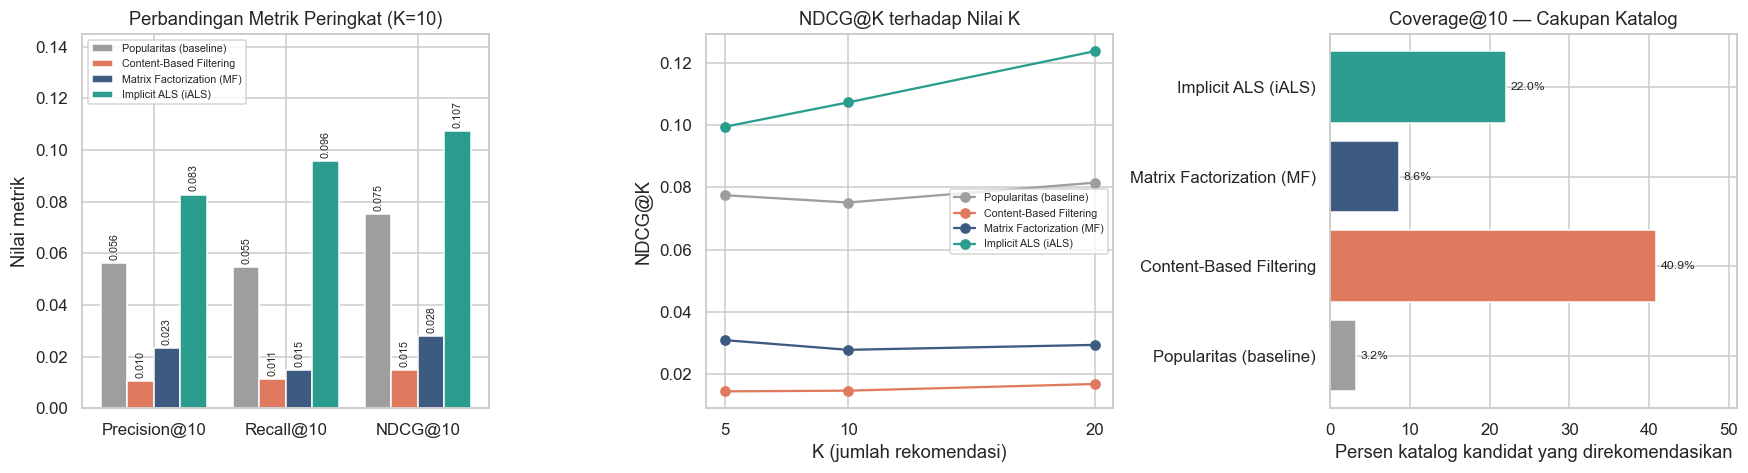

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
warna_model = {'Popularitas (baseline)': '#9e9e9e', 'Content-Based Filtering': '#e07a5f',
               'Matrix Factorization (MF)': '#3d5a80', 'Implicit ALS (iALS)': '#2a9d8f'}

metrik_bar = ['Precision@10', 'Recall@10', 'NDCG@10']
x = np.arange(len(metrik_bar))
lebar = 0.2
for j, (nama, _) in enumerate(model_untuk_ranking.items()):
    nilai = tabel_ranking.loc[tabel_ranking.Model == nama, metrik_bar].to_numpy().ravel()
    posisi = x + (j - 1.5) * lebar
    ax[0].bar(posisi, nilai, lebar, label=nama, color=warna_model[nama])
    for xp, v in zip(posisi, nilai):
        ax[0].text(xp, v + 0.002, f'{v:.3f}', ha='center', fontsize=7, rotation=90)
ax[0].set_xticks(x)
ax[0].set_xticklabels(metrik_bar)
ax[0].set_title('Perbandingan Metrik Peringkat (K=10)')
ax[0].set_ylabel('Nilai metrik')
ax[0].legend(fontsize=7)
ax[0].set_ylim(0, max(tabel_ranking[metrik_bar].to_numpy().max() * 1.35, 0.12))

for nama in model_untuk_ranking:
    sub = tabel_k[tabel_k.Model == nama].sort_values('K')
    ax[1].plot(sub.K, sub.NDCG, marker='o', label=nama, color=warna_model[nama])
ax[1].set_title('NDCG@K terhadap Nilai K')
ax[1].set_xlabel('K (jumlah rekomendasi)')
ax[1].set_ylabel('NDCG@K')
ax[1].set_xticks([5, 10, 20])
ax[1].legend(fontsize=7)

nilai_cov = tabel_ranking['Coverage@10'].to_numpy() * 100
ax[2].barh([n for n in model_untuk_ranking], nilai_cov,
           color=[warna_model[n] for n in model_untuk_ranking])
for i, v in enumerate(nilai_cov):
    ax[2].text(v + 0.6, i, f'{v:.1f}%', va='center', fontsize=8)
ax[2].set_title('Coverage@10 — Cakupan Katalog')
ax[2].set_xlabel('Persen katalog kandidat yang direkomendasikan')
ax[2].set_xlim(0, max(nilai_cov) * 1.25)

plt.tight_layout()
simpan_gambar('fig_07_perbandingan_model.png')
plt.show()

**Pembacaan hasil peringkat.** Tabel dan grafik di atas memuat empat temuan
utama.

1. **iALS adalah satu-satunya model yang benar-benar mengalahkan baseline
   populer**, dan selisihnya besar: Precision@10 naik 47%, Recall@10 naik 75%,
   dan NDCG@10 naik 43%. Sekitar satu dari dua belas judul yang
   direkomendasikannya benar-benar ditonton dan disukai pengguna pada periode
   berikutnya. Sekaligus, cakupan katalognya tujuh kali lebih luas daripada
   baseline populer — jadi keunggulan itu tidak diperoleh dengan cara
   mengulang-ulang film terkenal.
2. **MF justru kalah dari baseline populer** pada seluruh metrik peringkat,
   padahal ia adalah model dengan RMSE terbaik. Sebabnya sudah terlihat pada
   bagian 5.2: regularisasi ringan yang optimal bagi RMSE membiarkan film
   berdata sedikit memperoleh bias tinggi, dan film-film itulah yang membanjiri
   sepuluh besar. RMSE tidak pernah menghukum perilaku ini karena ia hanya
   dihitung pada rating yang teramati.
3. **CBF berada paling bawah pada ketepatan tetapi paling atas pada cakupan.**
   Ia menyentuh 40,9% katalog kandidat, sementara baseline populer hanya 3,2%.
   Pertukaran ini nyata dan perlu disadari: CBF memberi kesempatan hidup bagi
   film di ekor katalog, dengan harga ketepatan yang jauh lebih rendah.
4. **Urutan peringkat model stabil di semua nilai K.** Pada K = 5, 10, maupun
   20, susunannya tetap iALS > POP > MF > CBF, sehingga kesimpulan ini bukan
   kebetulan akibat pemilihan satu nilai K tertentu.

## 6.4 Analisis Tambahan — Performa Menurut Panjang Riwayat Pengguna

Angka rata-rata dapat menyembunyikan perbedaan perilaku antarsegmen pengguna.
Bagian ini memecah hasil menurut banyaknya film yang pernah ditonton seorang
pengguna pada data latih, untuk menguji dugaan umum bahwa *collaborative
filtering* melemah ketika riwayat pengguna pendek.

In [43]:
jumlah_tonton = sudah_ditonton.sum(axis=1)
batas_segmen = np.quantile([jumlah_tonton[u] for u in relevan_uji], [0.33, 0.66])


def segmen_pengguna(n):
    if n <= batas_segmen[0]:
        return f'Riwayat pendek (<= {int(batas_segmen[0])} film)'
    if n <= batas_segmen[1]:
        return f'Riwayat sedang ({int(batas_segmen[0]) + 1}-{int(batas_segmen[1])} film)'
    return f'Riwayat panjang (> {int(batas_segmen[1])} film)'


baris_segmen = []
for nama_segmen in sorted({segmen_pengguna(jumlah_tonton[u]) for u in relevan_uji},
                          key=lambda s: batas_segmen[0] if 'pendek' in s else (
                              batas_segmen[1] if 'sedang' in s else 1e9)):
    subset = {u: r for u, r in relevan_uji.items()
              if segmen_pengguna(jumlah_tonton[u]) == nama_segmen}
    catatan = {'Segmen': nama_segmen, 'Jumlah pengguna': len(subset)}
    for nama, skor in model_untuk_ranking.items():
        catatan[nama] = evaluasi_ranking(skor, subset, sudah_ditonton, pool, K=10)['NDCG@10']
    baris_segmen.append(catatan)

tabel_segmen = pd.DataFrame(baris_segmen)
print('--- NDCG@10 menurut panjang riwayat pengguna ---')
print(tabel_segmen.round(4).to_string(index=False))

--- NDCG@10 menurut panjang riwayat pengguna ---
                      Segmen  Jumlah pengguna  Popularitas (baseline)  Content-Based Filtering  Matrix Factorization (MF)  Implicit ALS (iALS)
 Riwayat pendek (<= 37 film)              198                  0.0609                   0.0154                     0.0082               0.1042
Riwayat sedang (38-103 film)              192                  0.0609                   0.0088                     0.0233               0.0902
Riwayat panjang (> 103 film)              196                  0.1034                   0.0199                     0.0521               0.1271


### Visualisasi Performa Antarsegmen

Perbandingan NDCG@10 keempat model pada tiga segmen panjang riwayat pengguna.

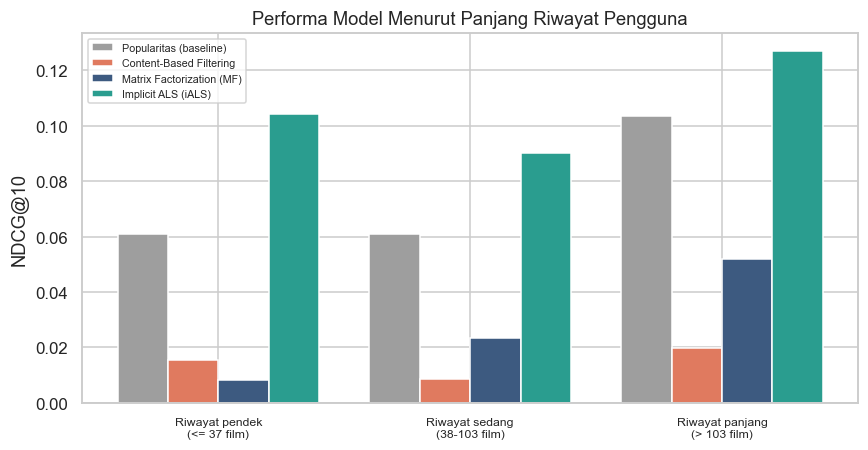

In [44]:
plt.figure(figsize=(8, 4.2))
x = np.arange(len(tabel_segmen))
lebar = 0.2
for j, nama in enumerate(model_untuk_ranking):
    plt.bar(x + (j - 1.5) * lebar, tabel_segmen[nama], lebar, label=nama, color=warna_model[nama])
plt.xticks(x, [s.replace(' (', '\n(') for s in tabel_segmen.Segmen], fontsize=8)
plt.ylabel('NDCG@10')
plt.title('Performa Model Menurut Panjang Riwayat Pengguna')
plt.legend(fontsize=7)
plt.tight_layout()
simpan_gambar('fig_08_segmen_pengguna.png')
plt.show()

**Pembacaan analisis segmen.** Dugaan awal ternyata hanya sebagian benar.
iALS memang bekerja paling baik pada pengguna berriwayat panjang (NDCG@10
0,127), tetapi pada pengguna berriwayat pendek pun ia tetap unggul (0,104) dan
masih jauh di atas baseline populer (0,061). Dengan kata lain, 20–37 film sudah
cukup bagi iALS untuk menangkap selera seseorang.

Sebaliknya, MF melemah drastis pada pengguna berriwayat pendek (0,008) — jauh di
bawah baseline populer. Pengguna dengan sedikit rating memiliki vektor laten yang
nyaris tak terlatih, sehingga peringkatnya hampir seluruhnya ditentukan bias film
yang, seperti sudah ditunjukkan, condong pada film klasik berdata sedikit.

CBF konsisten rendah di seluruh segmen. Ini menegaskan sekali lagi bahwa
kendalanya bukan pada banyak-sedikitnya data pengguna, melainkan pada resolusi
metadata yang tersedia.

## 6.5 Kelebihan dan Kekurangan Tiap Pendekatan

Tabel berikut merangkum temuan kuantitatif di atas menjadi penilaian
menyeluruh terhadap kedua pendekatan yang diajukan.

### Content-Based Filtering

**Kelebihan**

1. **Bebas dari masalah *cold-start item*.** Film baru dapat langsung
   direkomendasikan begitu genre-nya tercatat, tanpa perlu menunggu satu rating
   pun. Pada data uji ini, 8,4% rating menyangkut film yang tak dikenal
   *collaborative filtering* — seluruhnya dapat ditangani CBF.
2. **Cakupan katalog jauh lebih luas.** Coverage@10 CBF mencapai **40,9%**,
   tertinggi di antara seluruh model dan hampir tiga belas kali lipat baseline
   populer yang hanya menyentuh 3,2% katalog. CBF memberi kesempatan hidup bagi
   film di ekor distribusi.
3. **Dapat dijelaskan.** Alasan rekomendasi selalu tersedia dalam bahasa manusia:
   "karena Anda menyukai *Toy Story* yang beranimasi, bergenre keluarga, dan
   bertag *pixar*". Transparansi ini bernilai tinggi untuk membangun kepercayaan
   pengguna.
4. **Tidak bergantung pada pengguna lain.** Sistem tetap berfungsi bagi pengguna
   dengan selera tidak lazim yang tak punya "tetangga selera".

**Kekurangan**

1. **Ketepatannya paling rendah** di antara seluruh pendekatan: Precision@10
   hanya **0,010**, kurang dari seperlima baseline populer (0,056). Sebabnya
   jelas — metadata yang tersedia terlalu kasar untuk membedakan selera.
2. **Terkunci pada resolusi metadata.** Ratusan film berbagi kombinasi genre
   yang sama persis sehingga kemiripannya bernilai 1,000 dan tak dapat
   diperingkat secara bermakna — persoalan yang terlihat gamblang pada contoh
   *The Godfather*.
3. ***Over-specialization*.** Sistem hanya menawarkan hal serupa dengan yang
   sudah ditonton dan tidak pernah memperkenalkan kejutan menyenangkan, padahal
   justru itulah nilai utama sebuah sistem rekomendasi.
4. **Buta terhadap kualitas.** Kemiripan konten tidak tahu-menahu soal bagus
   atau buruknya sebuah film; film jelek bergenre sama tetap dinilai sangat mirip.

### Collaborative Filtering

**Kelebihan**

1. **Ketepatan tertinggi.** iALS mencapai Precision@10 **0,083**, Recall@10
   **0,096**, dan NDCG@10 **0,107** — masing-masing 47%, 75%, dan 43% di atas
   baseline populer, dan merupakan hasil terbaik di antara seluruh pendekatan.
2. **Menemukan pola yang tak terlihat pada metadata.** Model dapat mengaitkan
   film lintas genre semata-mata karena orang yang sama menyukai keduanya —
   sesuatu yang mustahil ditangkap CBF.
3. **Memperhitungkan kualitas dan bias secara eksplisit.** Suku $b_u$ dan $b_i$
   menormalkan perbedaan gaya menilai antarpengguna dan perbedaan mutu
   antarfilm, sehingga peringkat lebih adil.
4. **Meningkat seiring bertambahnya data.** NDCG@10 iALS naik dari 0,104 pada
   pengguna berriwayat pendek menjadi 0,127 pada pengguna berriwayat panjang.
   Yang menggembirakan, bahkan pada segmen terpendek pun ia sudah mengungguli
   baseline populer.

**Kekurangan**

1. ***Cold-start* pada dua sisi.** Film tanpa rating tidak memiliki vektor laten
   yang bermakna, dan pengguna baru tidak memiliki profil sama sekali.
2. **Cakupan katalog lebih sempit daripada CBF** (22,0% berbanding 40,9%),
   karena model condong pada film yang punya cukup bukti interaksi.
3. **Sulit dijelaskan.** Faktor laten tidak memiliki makna yang dapat
   diverbalkan, sehingga alasan rekomendasi sukar dikomunikasikan kepada pengguna.
4. **Metrik optimasi harus dipilih dengan hati-hati.** Ini temuan terpenting
   proyek ini: MF memenangi RMSE (0,880) tetapi NDCG@10-nya hanya **0,028**,
   seperempat dari iALS (**0,107**) yang bahkan tidak dapat memprediksi rating
   sama sekali — dan MF pun kalah dari baseline populer (0,075). Melatih model
   untuk menebak angka ternyata bukan cara terbaik untuk menyusun peringkat.

## 6.6 Ringkasan Seluruh Hasil Evaluasi

In [45]:
ringkasan_akhir = tabel_ranking.copy()
ringkasan_akhir['RMSE (uji)'] = [
    np.nan,
    np.nan,
    float(tabel_rating.loc[tabel_rating.Model == 'Matrix Factorization (MF)', 'RMSE'].iloc[0]),
    np.nan,
]
ringkasan_akhir['Pendekatan'] = ['Baseline non-personal', 'Content-based filtering',
                                 'Collaborative filtering (eksplisit)',
                                 'Collaborative filtering (implisit)']
ringkasan_akhir = ringkasan_akhir[['Model', 'Pendekatan', 'Precision@10', 'Recall@10',
                                   'NDCG@10', 'Coverage@10', 'RMSE (uji)']]

print('=' * 110)
print('RINGKASAN AKHIR — SELURUH MODEL PADA DATA UJI')
print('=' * 110)
print(ringkasan_akhir.round(4).to_string(index=False))
print('\nCatatan: RMSE hanya berlaku bagi model yang memprediksi nilai rating.')
print('         POP, CBF, dan iALS menghasilkan skor preferensi, bukan taksiran rating.')

RINGKASAN AKHIR — SELURUH MODEL PADA DATA UJI
                    Model                          Pendekatan  Precision@10  Recall@10  NDCG@10  Coverage@10  RMSE (uji)
   Popularitas (baseline)               Baseline non-personal        0.0563     0.0548   0.0751       0.0322         NaN
  Content-Based Filtering             Content-based filtering        0.0104     0.0112   0.0147       0.4087         NaN
Matrix Factorization (MF) Collaborative filtering (eksplisit)        0.0232     0.0148   0.0278       0.0859      0.8796
      Implicit ALS (iALS)  Collaborative filtering (implisit)        0.0828     0.0957   0.1073       0.2201         NaN

Catatan: RMSE hanya berlaku bagi model yang memprediksi nilai rating.
         POP, CBF, dan iALS menghasilkan skor preferensi, bukan taksiran rating.


---
# 7. Kesimpulan

Proyek ini membangun dan membandingkan dua pendekatan sistem rekomendasi film
di atas dataset MovieLens berisi 100.836 rating dari 610 pengguna terhadap 9.742
film, dengan protokol evaluasi temporal yang meniru kondisi produksi.

**Menjawab pernyataan masalah**

1. **Bagaimana merekomendasikan film yang relevan tanpa harus menunggu pengguna
   menjelajah katalog sendiri?** Keduanya berhasil menghasilkan top-N
   rekomendasi yang berfungsi, tetapi dengan mutu yang berbeda jauh. iALS
   memberikan hasil terbaik: kurang lebih satu dari dua belas film yang
   disodorkannya benar-benar ditonton dan disukai pengguna pada periode
   berikutnya, tanpa pengguna perlu mencari apa pun.

2. **Bagaimana menangani film yang jarang atau belum pernah dirating?** CBF
   menjawab persoalan ini secara langsung — ia mampu menilai film mana pun yang
   memiliki metadata, termasuk 8,4% rating uji yang menyangkut film tak dikenal
   *collaborative filtering*, dan mencapai cakupan katalog tertinggi. Namun
   harga yang dibayar adalah ketepatan yang jauh lebih rendah.

3. **Pendekatan mana yang lebih tepat dan bagaimana membuktikannya?**
   *Collaborative filtering* dengan iALS terbukti unggul secara kuantitatif pada
   seluruh metrik ketepatan peringkat, dan pembuktiannya sahih karena
   menggunakan baseline populer sebagai pembanding, penyetelan *hyperparameter*
   yang terpisah dari data uji, serta protokol evaluasi yang identik bagi semua
   model.

**Temuan metodologis yang paling penting**

Model dengan RMSE terbaik **bukanlah** model dengan rekomendasi terbaik. MF
unggul dalam menebak angka rating, sementara iALS — yang bahkan tidak
memprediksi rating — jauh mengungguli MF dalam menyusun peringkat sepuluh besar.
Pelajarannya: metrik evaluasi harus dipilih berdasarkan **apa yang benar-benar
dilihat pengguna**, bukan berdasarkan apa yang paling mudah dihitung.

**Keterbatasan dan arah pengembangan**

1. **Hibridisasi.** CBF dan CF memiliki kelemahan yang saling melengkapi.
   Menggabungkan skor keduanya — misalnya menyerahkan pengguna dan film baru
   kepada CBF, lalu beralih ke iALS setelah interaksi cukup terkumpul — adalah
   langkah lanjutan yang paling menjanjikan.
2. **Metadata yang lebih kaya.** Sutradara, pemeran, sinopsis, dan *tag genome*
   akan menaikkan resolusi representasi konten jauh di atas 19 genre yang
   tersedia sekarang.
3. **Skala data.** Dengan 610 pengguna, model kolaboratif bekerja pada data yang
   sangat terbatas. Versi MovieLens 25M akan memberi gambaran performa yang lebih
   representatif.
4. **Evaluasi daring.** Seluruh angka pada laporan ini berasal dari evaluasi
   luring pada data historis. Ukuran keberhasilan yang sesungguhnya — apakah
   pengguna benar-benar menonton yang direkomendasikan — hanya dapat diperoleh
   melalui pengujian A/B pada sistem nyata.

---
## Referensi

1. Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and
   Context. *ACM Transactions on Interactive Intelligent Systems*, 5(4), 1–19.
   <https://doi.org/10.1145/2827872>
2. Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix Factorization Techniques
   for Recommender Systems. *Computer*, 42(8), 30–37.
   <https://doi.org/10.1109/MC.2009.263>
3. Hu, Y., Koren, Y., & Volinsky, C. (2008). Collaborative Filtering for Implicit
   Feedback Datasets. *IEEE International Conference on Data Mining (ICDM)*,
   263–272. <https://doi.org/10.1109/ICDM.2008.22>
4. Lops, P., de Gemmis, M., & Semeraro, G. (2011). Content-based Recommender
   Systems: State of the Art and Trends. Dalam *Recommender Systems Handbook*
   (hlm. 73–105). Springer. <https://doi.org/10.1007/978-0-387-85820-3_3>
5. Cremonesi, P., Koren, Y., & Turrin, R. (2010). Performance of Recommender
   Algorithms on Top-N Recommendation Tasks. *Proceedings of the Fourth ACM
   Conference on Recommender Systems*, 39–46.
   <https://doi.org/10.1145/1864708.1864721>
6. Järvelin, K., & Kekäläinen, J. (2002). Cumulated Gain-based Evaluation of IR
   Techniques. *ACM Transactions on Information Systems*, 20(4), 422–446.
   <https://doi.org/10.1145/582415.582418>